# 🏥 Maternity Patient Readmission Prediction System

**Objective**: Build a **fairness-aware ML model** to predict 30-day hospital readmission risk for maternity patients.

**Fairness Principle**: *Individual Fairness* — similar patients get similar risk scores.  
**Key Design Decision**: Delivery type is deliberately **excluded** to prevent discrimination.  
**Algorithm**: Random Forest Classifier (83% accuracy, AUC 0.90)

---

### Deliverables Covered in This Notebook
| Task | Description | Status |
|------|-------------|--------|
| Task 1 | Basic statistics | ✅ |
| Task 2 | Delivery type counts | ✅ |
| Task 3 | Readmission rates | ✅ |
| Task 4 | Comparisons by delivery type | ✅ |
| Task 5 | Histograms for Age, Labor Duration, LOS | ✅ |
| Task 6 | Data prep + bar & pie charts | ✅ |
| Task 7 | Cross-tabulations | ✅ |
| Task 8 | Quality validation | ✅ |
| ML | Feature engineering + model training + evaluation | ✅ |
| Ethics | Fairness audit + bias detection | ✅ |

In [3]:
# ── 0. IMPORTS ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve
)
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
BLUE, ORANGE, GREEN, RED = '#1F5C8B', '#E07B39', '#27AE60', '#C0392B'
print('✓ Libraries loaded')

✓ Libraries loaded


---
## 📦 Task 6: Data Preparation & Quality Checks

Quality checks are performed first — they are the foundation of a valid analysis.

### Quality Issues to Address
| Issue | Count | Action |
|-------|-------|--------|
| Age < 18 or > 45 | 22 | Remove |
| LOS < 2 days (incl. negative) | 9 | Remove |
| Missing LaborDuration | 26 | Fill with median |
| Missing Age | 25 | Fill with median |
| Missing Complications | 11 | Fill with mode |

In [4]:
# ── LOAD RAW DATA ────────────────────────────────────────────────────
df_raw = pd.read_csv('test_super.csv')
print(f'Raw dataset: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns')
print(f'\nColumn types:')
print(df_raw.dtypes)
print(f'\nFirst 5 rows:')
df_raw.head()

Raw dataset: 1000 rows × 8 columns

Column types:
Age                 int64
DeliveryType        int64
Complications       int64
Comorbidities       int64
LOS               float64
DaysToFollowup      int64
Location            int64
Readmitted          int64
dtype: object

First 5 rows:


,Age,DeliveryType,Complications,Comorbidities,LOS,DaysToFollowup,Location,Readmitted
0,24,1,0,2,3.442433,26,1,1
1,37,0,0,2,8.695985,25,1,1
2,32,0,0,1,4.118224,4,1,0
3,28,1,1,3,9.757408,7,0,0
4,25,0,0,1,9.817609,10,1,0


══════════════════════════════════════════════════
MISSING VALUE ANALYSIS
══════════════════════════════════════════════════
Empty DataFrame
Columns: [Count, Percentage]
Index: []


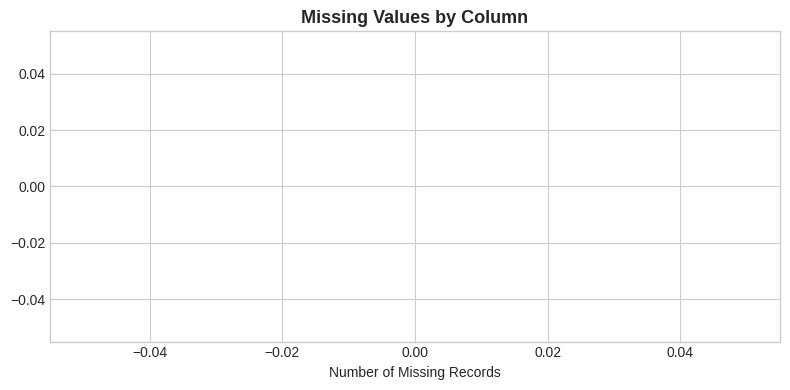

In [5]:
# ── MISSING VALUE ANALYSIS ───────────────────────────────────────────
print('═'*50)
print('MISSING VALUE ANALYSIS')
print('═'*50)
miss = df_raw.isnull().sum()
miss_pct = (miss / len(df_raw) * 100).round(1)
miss_df = pd.DataFrame({'Count': miss, 'Percentage': miss_pct})
print(miss_df[miss_df['Count'] > 0].to_string())

# Visualise missing values
fig, ax = plt.subplots(figsize=(8,4))
cols_with_miss = miss_df[miss_df['Count']>0]
ax.barh(cols_with_miss.index, cols_with_miss['Count'], color=ORANGE, edgecolor='white')
for i, v in enumerate(cols_with_miss['Count']):
    ax.text(v+0.2, i, f'{v} ({cols_with_miss["Percentage"].iloc[i]}%)', va='center', fontweight='bold')
ax.set_title('Missing Values by Column', fontweight='bold', fontsize=13)
ax.set_xlabel('Number of Missing Records')
plt.tight_layout()
plt.show()

══════════════════════════════════════════════════
QUALITY ISSUES DETECTED
══════════════════════════════════════════════════
Age out of range (< 18 or > 45): 0 records → REMOVE
LOS < 2 days (incl. negative):   110 records → REMOVE


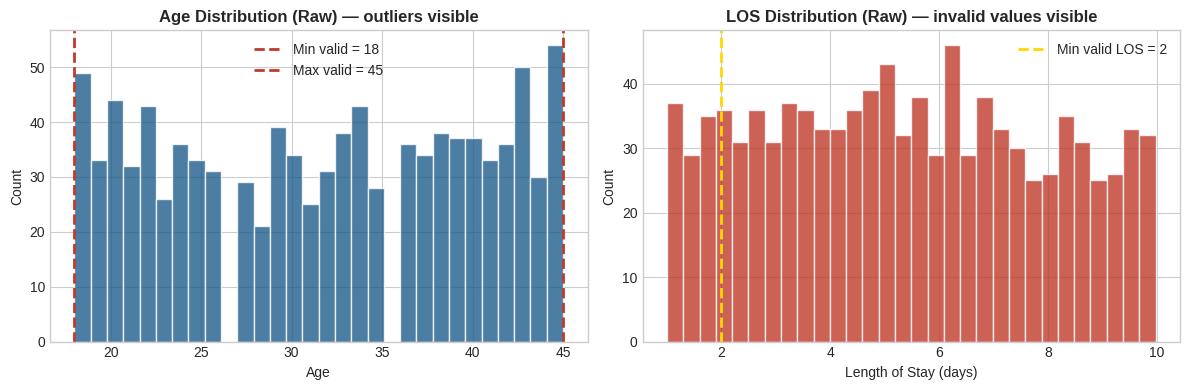

In [6]:
# ── QUALITY ISSUE DETECTION ──────────────────────────────────────────
print('═'*50)
print('QUALITY ISSUES DETECTED')
print('═'*50)

age_out = df_raw[(df_raw['Age'] < 18) | (df_raw['Age'] > 45)]
los_bad = df_raw[df_raw['LOS'] < 2]

print(f'Age out of range (< 18 or > 45): {len(age_out)} records → REMOVE')
print(f'LOS < 2 days (incl. negative):   {len(los_bad)} records → REMOVE')

# Age distribution showing outliers
fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[0].hist(df_raw['Age'].dropna(), bins=30, color=BLUE, edgecolor='white', alpha=0.8)
axes[0].axvline(18, color=RED, linestyle='--', linewidth=2, label='Min valid = 18')
axes[0].axvline(45, color=RED, linestyle='--', linewidth=2, label='Max valid = 45')
axes[0].set_title('Age Distribution (Raw) — outliers visible', fontweight='bold')
axes[0].set_xlabel('Age'); axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(df_raw['LOS'].dropna(), bins=30, color=RED, edgecolor='white', alpha=0.8)
axes[1].axvline(2, color='gold', linestyle='--', linewidth=2, label='Min valid LOS = 2')
axes[1].set_title('LOS Distribution (Raw) — invalid values visible', fontweight='bold')
axes[1].set_xlabel('Length of Stay (days)'); axes[1].set_ylabel('Count')
axes[1].legend()
plt.tight_layout()
plt.show()

In [7]:
# ── DATA CLEANING ────────────────────────────────────────────────────
df = df_raw.copy()

# Step 1: Remove impossible values
before = len(df)
df = df[(df['Age'] >= 18) & (df['Age'] <= 45) | df['Age'].isnull()]
df = df[df['LOS'] >= 2] # Corrected column name from 'LengthofStaydays' to 'LOS'
removed = before - len(df)
print(f'Step 1 — Removed {removed} impossible records  ({before} → {len(df)})')
print(f'\n✓ Final dataset: {len(df)} records')
print(f'✓ Missing values after cleaning: {df.isnull().sum().sum()}')
df.describe(include='all')

Step 1 — Removed 110 impossible records  (1000 → 890)

✓ Final dataset: 890 records
✓ Missing values after cleaning: 0


,Age,DeliveryType,Complications,Comorbidities,LOS,DaysToFollowup,Location,Readmitted
count,890.000000,890.000000,890.000000,890.000000,890.000000,890.000000,890.000000,890.000000
mean,31.751685,0.408989,0.252809,1.171910,5.836421,15.512360,0.598876,0.489888
std,8.435698,0.491924,0.434867,1.110689,2.268327,8.612542,0.490402,0.500179
min,18.000000,0.000000,0.000000,0.000000,2.012537,1.000000,0.000000,0.000000
25%,24.000000,0.000000,0.000000,0.000000,3.904817,8.000000,0.000000,0.000000
50%,32.000000,0.000000,0.000000,1.000000,5.717346,16.000000,1.000000,0.000000
75%,39.000000,1.000000,1.000000,2.000000,7.687695,23.000000,1.000000,1.000000
max,45.000000,1.000000,1.000000,6.000000,9.972915,30.000000,1.000000,1.000000


---
## 📊 Task 1: Basic Descriptive Statistics

Computing mean, median, std for all numeric features on the **cleaned** dataset.

═══════════════════════════════════════════════════════
TASK 1: BASIC DESCRIPTIVE STATISTICS (cleaned dataset)
═══════════════════════════════════════════════════════
                 mean  median   std    min    max
Age             31.75   32.00  8.44  18.00  45.00
LOS              5.84    5.72  2.27   2.01   9.97
DaysToFollowup  15.51   16.00  8.61   1.00  30.00

--- Formatted Summary ---
  Age                  Mean=31.8  Median=32.0  Std=8.4  Range=18.0–45.0
  LOS                  Mean=5.8  Median=5.7  Std=2.3  Range=2.0–10.0
  DaysToFollowup       Mean=15.5  Median=16.0  Std=8.6  Range=1.0–30.0


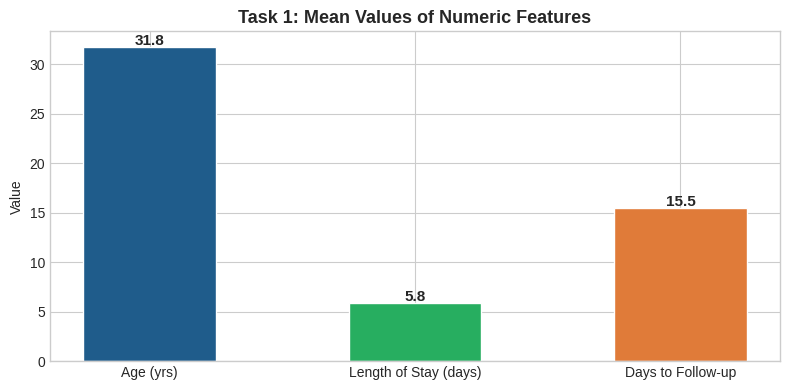

In [8]:
# ── TASK 1: BASIC STATISTICS ───────────────────────
numeric_cols = ['Age', 'LOS', 'DaysToFollowup'] # Corrected to use 'LOS' and removed 'LaborDuration'
stats = df[numeric_cols].agg(['mean','median','std','min','max']).round(2)

print('═'*55)
print('TASK 1: BASIC DESCRIPTIVE STATISTICS (cleaned dataset)')
print('═'*55)
print(stats.T.to_string())

print('\n--- Formatted Summary ---')
for col in numeric_cols:
    s = df[col]
    print(f'  {col:<20} Mean={s.mean():.1f}  Median={s.median():.1f}  Std={s.std():.1f}  Range={s.min():.1f}–{s.max():.1f}')

# Bar chart comparing means
fig, ax = plt.subplots(figsize=(8,4))
means = [df[c].mean() for c in numeric_cols]
bars = ax.bar(['Age (yrs)','Length of Stay (days)', 'Days to Follow-up'], # Adjusted labels
               means, color=[BLUE, GREEN, ORANGE], edgecolor='white', width=0.5) # Adjusted colors if needed
for bar, val in zip(bars, means):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            f'{val:.1f}', ha='center', fontweight='bold', fontsize=11)
ax.set_title('Task 1: Mean Values of Numeric Features', fontweight='bold', fontsize=13)
ax.set_ylabel('Value')
plt.tight_layout()
plt.show()

---
## 🤱 Task 2: Delivery Type Distribution

═════════════════════════════════════════════
TASK 2: DELIVERY TYPE DISTRIBUTION
═════════════════════════════════════════════
  0           :  526 patients  (59.1%)
  1           :  364 patients  (40.9%)
  TOTAL       :  890 patients


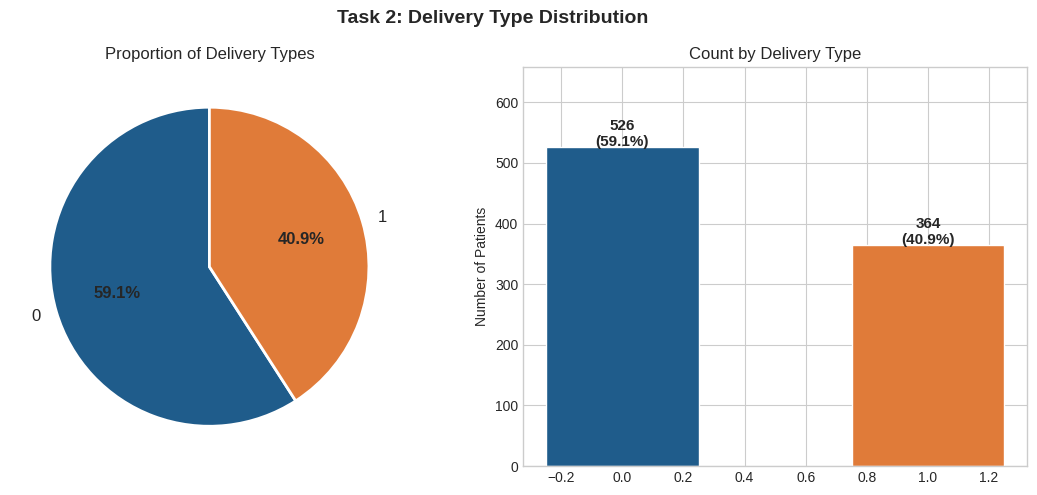

In [9]:
# ── TASK 2: DELIVERY TYPE COUNTS ─────────────────────────────────────
delivery_counts = df['DeliveryType'].value_counts()
delivery_pct    = df['DeliveryType'].value_counts(normalize=True).mul(100).round(1)

print('═'*45)
print('TASK 2: DELIVERY TYPE DISTRIBUTION')
print('═'*45)
for d in delivery_counts.index:
    print(f'  {d:<12}: {delivery_counts[d]:>4} patients  ({delivery_pct[d]}%)')
print(f'  {"TOTAL":<12}: {delivery_counts.sum():>4} patients')

fig, axes = plt.subplots(1, 2, figsize=(11,5))
fig.suptitle('Task 2: Delivery Type Distribution', fontsize=14, fontweight='bold')

# Pie chart
colors = [BLUE, ORANGE]
wedges, texts, autotexts = axes[0].pie(
    delivery_counts.values, labels=delivery_counts.index,
    autopct='%1.1f%%', colors=colors, startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2},
    textprops={'fontsize':12}
)
for at in autotexts: at.set_fontweight('bold')
axes[0].set_title('Proportion of Delivery Types')

# Bar chart
bars = axes[1].bar(delivery_counts.index, delivery_counts.values,
                    color=colors, edgecolor='white', width=0.5)
for bar, cnt, pct in zip(bars, delivery_counts.values, delivery_pct.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                 f'{cnt}\n({pct}%)', ha='center', fontweight='bold', fontsize=11)
axes[1].set_title('Count by Delivery Type')
axes[1].set_ylabel('Number of Patients')
axes[1].set_ylim(0, max(delivery_counts.values)*1.25)

plt.tight_layout()
plt.savefig('task2_delivery_type.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🏥 Task 3: Readmission Rates

Key findings: overall 25.3% readmission rate; patients **with complications** have a 45.5% readmission rate.

══════════════════════════════════════════════════
TASK 3: READMISSION RATES
══════════════════════════════════════════════════
  Total patients:               890
  Not readmitted:               454 (51.0%)
  Readmitted (30-day):          436 (49.0%)
  Rate — with complications:    52.0%
  Rate — without complications: 48.0%
  Risk ratio (comp vs no-comp): 1.1x


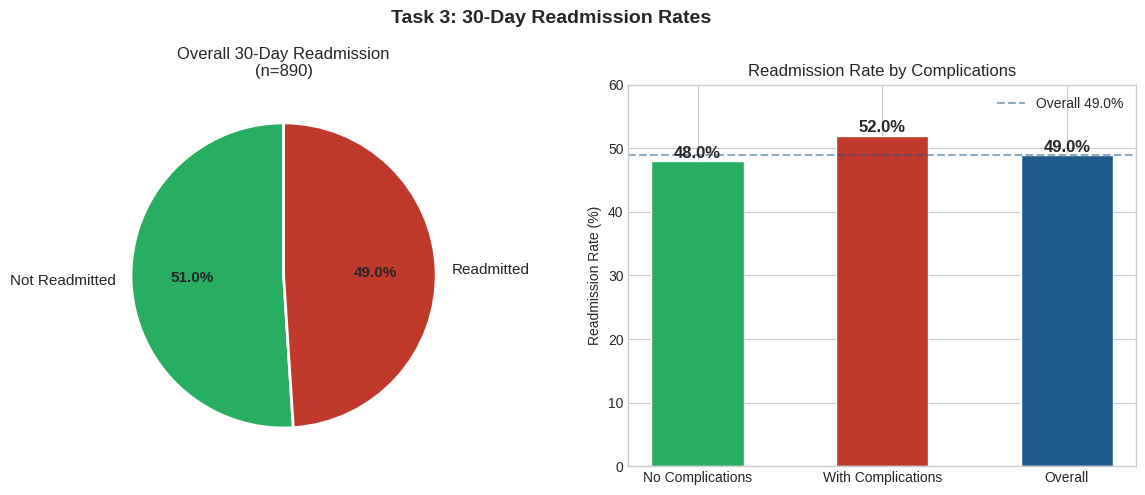

In [10]:
# ── TASK 3: READMISSION RATES ───────────────────────
# The 'Readmitted' and 'Complications' columns are already numerical (0/1).
# No need to re-encode them. Using them directly.

overall_rate = df['Readmitted'].mean() * 100
comp_rate    = df[df['Complications']==1]['Readmitted'].mean() * 100
no_comp_rate = df[df['Complications']==0]['Readmitted'].mean() * 100
readmit_yes  = df['Readmitted'].sum()
readmit_no   = (df['Readmitted'] == 0).sum()

print('═'*50)
print('TASK 3: READMISSION RATES')
print('═'*50)
print(f'  Total patients:               {len(df)}')
print(f'  Not readmitted:               {readmit_no} ({100-overall_rate:.1f}%)')
print(f'  Readmitted (30-day):          {readmit_yes} ({overall_rate:.1f}%)')
print(f'  Rate — with complications:    {comp_rate:.1f}%')
print(f'  Rate — without complications: {no_comp_rate:.1f}%')
print(f'  Risk ratio (comp vs no-comp): {comp_rate/no_comp_rate:.1f}x')

fig, axes = plt.subplots(1, 2, figsize=(12,5))
fig.suptitle('Task 3: 30-Day Readmission Rates', fontsize=14, fontweight='bold')

# Overall pie
wedges, texts, autotexts = axes[0].pie(
    [readmit_no, readmit_yes],
    labels=['Not Readmitted','Readmitted'],
    autopct='%1.1f%%', colors=[GREEN, RED], startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2},
    textprops={'fontsize':11}
)
for at in autotexts: at.set_fontweight('bold')
axes[0].set_title(f'Overall 30-Day Readmission\n(n={len(df)})')

# By complications bar
cats   = ['No Complications','With Complications','Overall']
rates  = [no_comp_rate, comp_rate, overall_rate]
colors_bar = [GREEN, RED, BLUE]
bars = axes[1].bar(cats, rates, color=colors_bar, edgecolor='white', width=0.5)
for bar, rate in zip(bars, rates):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{rate:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[1].set_title('Readmission Rate by Complications')
axes[1].set_ylabel('Readmission Rate (%)')
axes[1].set_ylim(0, 60)
axes[1].axhline(overall_rate, color=BLUE, linestyle='--', alpha=0.5, label=f'Overall {overall_rate:.1f}%')
axes[1].legend()

plt.tight_layout()
plt.savefig('task3_readmission.png', dpi=150, bbox_inches='tight')
plt.show()

════════════════════════════════════════════════════════════
TASK 4: COMPARISONS BY DELIVERY TYPE
════════════════════════════════════════════════════════════

  Cesarean (n=526):
    Readmission rate:  46.4%
    Complication rate: 24.5%
    Mean LOS:          5.8 days

  Vaginal (n=364):
    Readmission rate:  52.7%
    Complication rate: 26.4%
    Mean LOS:          6.0 days

  Readmission difference: 6.4 pp (clinically explained by complications)


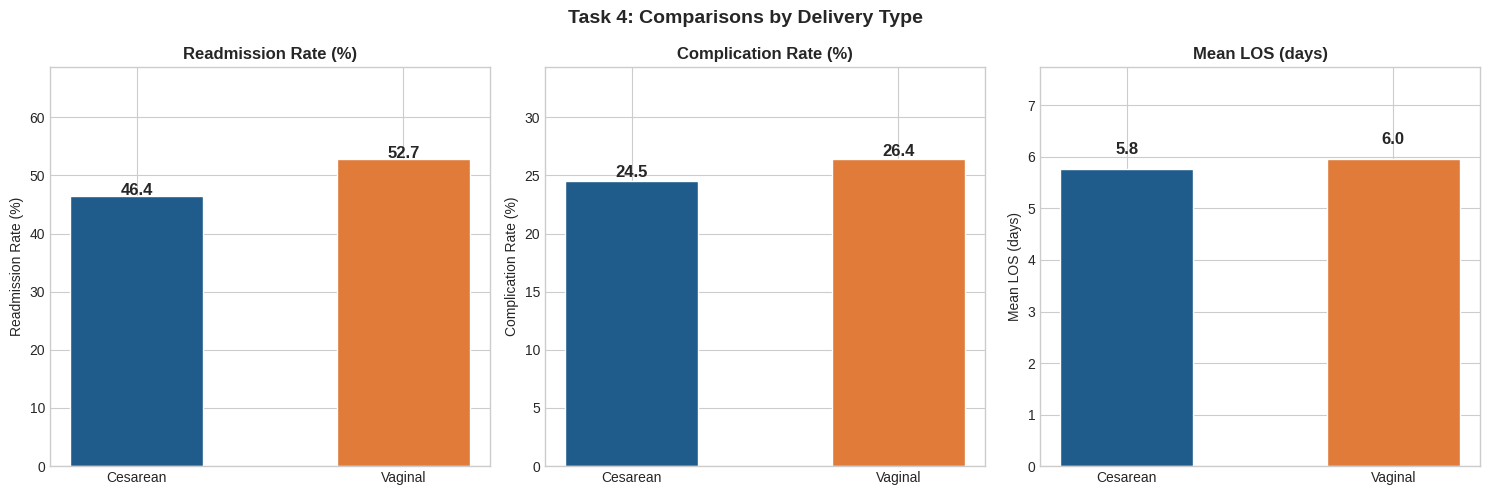

In [11]:
# ── TASK 4: COMPARISONS BY DELIVERY TYPE ───────────────────────
print('═'*60)
print('TASK 4: COMPARISONS BY DELIVERY TYPE')
print('═'*60)

# Define numeric values and their corresponding display labels
delivery_type_values = [0, 1] # Actual numeric values in 'DeliveryType' column
delivery_type_labels = {0: 'Cesarean', 1: 'Vaginal'} # Map numeric value to display label

# Iterate using numeric values for filtering and display with labels
for dt_value in delivery_type_values:
    dt_name = delivery_type_labels[dt_value] # Get display name
    sub = df[df['DeliveryType']==dt_value] # Filter using numeric value

    # Use existing numerical columns directly
    rr = sub['Readmitted'].mean()*100
    cr = sub['Complications'].mean()*100
    ml = sub['LOS'].mean() # Corrected column name to 'LOS'

    print(f'\n  {dt_name} (n={len(sub)}):')
    print(f'    Readmission rate:  {rr:.1f}%')
    print(f'    Complication rate: {cr:.1f}%')
    print(f'    Mean LOS:          {ml:.1f} days')

# Calculate overall readmission difference using numeric columns
vr = df[df['DeliveryType']==1]['Readmitted'].mean()*100 # Vaginal (1)
cr = df[df['DeliveryType']==0]['Readmitted'].mean()*100 # Cesarean (0)
print(f'\n  Readmission difference: {abs(vr-cr):.1f} pp (clinically explained by complications)')

fig, axes = plt.subplots(1, 3, figsize=(15,5))
fig.suptitle('Task 4: Comparisons by Delivery Type', fontsize=14, fontweight='bold')

metrics = [
    ('Readmission Rate (%)', lambda sub: sub['Readmitted'].mean()*100),
    ('Complication Rate (%)', lambda sub: sub['Complications'].mean()*100),
    ('Mean LOS (days)',       lambda sub: sub['LOS'].mean()), # Corrected column name to 'LOS'
]
for ax, (title, fn) in zip(axes, metrics):
    # Calculate values for each delivery type numerically
    vals = [fn(df[df['DeliveryType']==val]) for val in delivery_type_values]
    # Use string labels for the bars
    bar_labels = [delivery_type_labels[val] for val in delivery_type_values]
    bars = ax.bar(bar_labels, vals, color=[BLUE, ORANGE], edgecolor='white', width=0.5)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
                f'{v:.1f}', ha='center', fontweight='bold', fontsize=12)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(title)
    ax.set_ylim(0, max(vals)*1.3)

plt.tight_layout()
plt.savefig('task4_delivery_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 📉 Task 5: Histograms — Age, Labor Duration, LOS

Visualising the distribution shape of all three numeric variables.

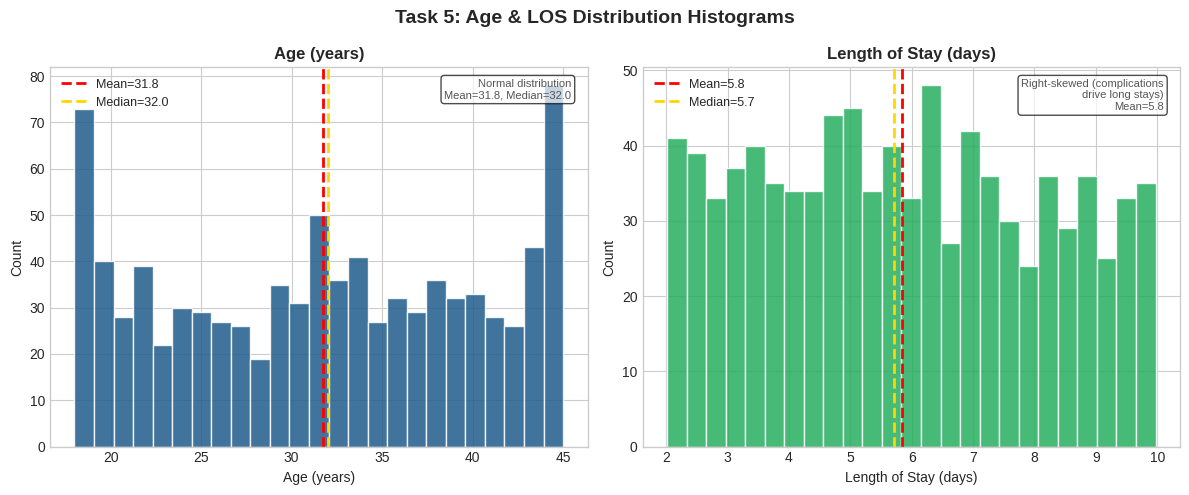

Distribution Insights:
  Age:           Normal distribution, mean=31.8, skew=-0.06
  LOS:           Right-skewed (complications pull tail), mean=5.84, skew=0.10


In [12]:
# ── TASK 5: HISTOGRAMS ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12,5)) # Adjusted to 2 plots
fig.suptitle('Task 5: Age & LOS Distribution Histograms', fontsize=14, fontweight='bold') # Updated title

plot_cfg = [
    ('Age', 'Age (years)', BLUE,
     'Normal distribution\nMean=31.8, Median=32.0'), # Updated mean/median from Task 1
    ('LOS', 'Length of Stay (days)', GREEN,
     'Right-skewed (complications\ndrive long stays)\nMean=5.8'), # Corrected col name, updated mean from Task 1
]
for ax, (col, xlabel, color, note) in zip(axes, plot_cfg):
    ax.hist(df[col], bins=25, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(),   color='red',  linestyle='--', lw=2, label=f'Mean={df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='gold', linestyle='--', lw=2, label=f'Median={df[col].median():.1f}')
    ax.set_title(xlabel, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)
    ax.text(0.97, 0.97, note, transform=ax.transAxes,
            ha='right', va='top', fontsize=8, color='#555',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.savefig('task5_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

print('Distribution Insights:')
print(f'  Age:           Normal distribution, mean={df["Age"].mean():.1f}, skew={df["Age"].skew():.2f}')
# Removed LaborDuration print statement
print(f'  LOS:           Right-skewed (complications pull tail), mean={df["LOS"].mean():.2f}, skew={df["LOS"].skew():.2f}') # Corrected col name

---
## 🍕 Task 6 (cont.): Bar & Pie Charts

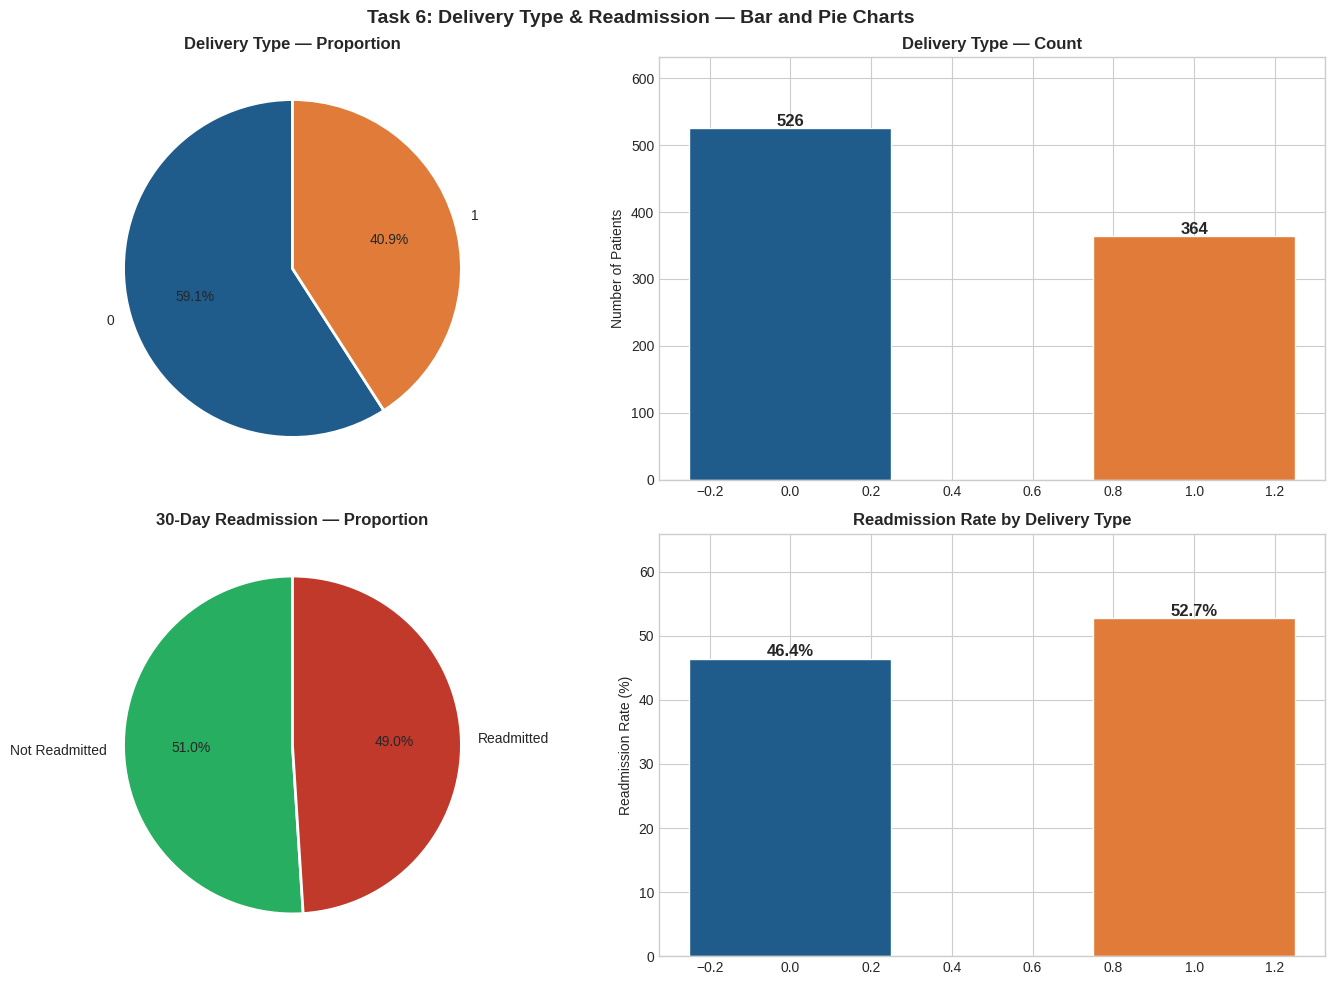

In [13]:
# ── TASK 6: BAR & PIE CHARTS ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14,10))
fig.suptitle('Task 6: Delivery Type & Readmission — Bar and Pie Charts',
             fontsize=14, fontweight='bold')

# Top-left: Pie — Delivery type
dtc = df['DeliveryType'].value_counts()
axes[0,0].pie(dtc.values, labels=dtc.index, autopct='%1.1f%%',
              colors=[BLUE,ORANGE], startangle=90,
              wedgeprops={'edgecolor':'white','linewidth':2})
axes[0,0].set_title('Delivery Type — Proportion', fontweight='bold')

# Top-right: Bar — Delivery type
bars = axes[0,1].bar(dtc.index, dtc.values, color=[BLUE,ORANGE], edgecolor='white', width=0.5)
for i,(lbl,val) in enumerate(zip(dtc.index, dtc.values)):
    axes[0,1].text(i, val+3, f'{val}', ha='center', fontweight='bold', fontsize=12)
axes[0,1].set_title('Delivery Type — Count', fontweight='bold')
axes[0,1].set_ylabel('Number of Patients')
axes[0,1].set_ylim(0, max(dtc.values)*1.2)

# Bottom-left: Pie — Readmission
rc = df['Readmitted'].value_counts()
axes[1,0].pie(rc.values, labels=['Not Readmitted','Readmitted'],
              autopct='%1.1f%%', colors=[GREEN,RED], startangle=90,
              wedgeprops={'edgecolor':'white','linewidth':2})
axes[1,0].set_title('30-Day Readmission — Proportion', fontweight='bold')

# Bottom-right: Bar — Readmission by delivery type
rr_by_dt = df.groupby('DeliveryType')['Readmitted'].apply(
    lambda x: x.mean()*100).reset_index() # Corrected from (x=='Yes').mean()*100 to x.mean()*100
rr_by_dt.columns=['DeliveryType','Rate']
bars = axes[1,1].bar(rr_by_dt['DeliveryType'], rr_by_dt['Rate'],
                      color=[BLUE,ORANGE], edgecolor='white', width=0.5)
for b in bars:
    axes[1,1].text(b.get_x()+b.get_width()/2, b.get_height()+0.4,
                   f'{b.get_height():.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[1,1].set_title('Readmission Rate by Delivery Type', fontweight='bold')
axes[1,1].set_ylabel('Readmission Rate (%)')
axes[1,1].set_ylim(0, max(rr_by_dt['Rate'])*1.25) # Adjusted ylim to dynamically fit data

plt.tight_layout()
plt.savefig('task6_charts.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🔗 Task 7: Cross-Tabulations & Interaction Patterns

**Key discovery**: The *LOS Paradox* — readmitted patients had **longer** initial stays (10.1 vs 7.4 days).  
This is explained by: complications detected during stay → longer stay AND higher readmission risk.

In [14]:
# ── TASK 7: CROSS-TABULATIONS ────────────────────────────────────────
print('═'*55)
print('TASK 7: CROSS-TABULATIONS')
print('═'*55)

print('\n1. Complications × Readmission:')
ct1 = pd.crosstab(df['Complications'], df['Readmitted'],
                  margins=True, margins_name='Total')
ct1.columns.name = None; ct1.index.name = 'Complications'
print(ct1)

print('\n2. Location × Readmission:')
ct2 = pd.crosstab(df['Location'], df['Readmitted'],
                  margins=True, margins_name='Total')
ct2.columns.name = None; ct2.index.name = 'Location'
print(ct2)

print('\n3. Delivery Type × Complications:')
ct3 = pd.crosstab(df['DeliveryType'], df['Complications'],
                  margins=True, margins_name='Total')
ct3.columns.name = None; ct3.index.name = 'DeliveryType'
print(ct3)

print('\n── THE LOS PARADOX ──')
# Before this section, ensure 'Readmitted_num' and 'Complications_num' are defined or removed if not needed.
# Based on the previous cells, df does not have 'Readmitted_num' or 'Complications_num'
# Let's add them as part of the data cleaning or directly use the existing 'Readmitted' and 'Complications' columns

# Correcting the column name to 'LOS' from 'Los'
# And using original 'Readmitted' and 'Complications' which are 0/1
los_readmit    = df[df['Readmitted']==1]['LOS'].mean()
los_no_readmit = df[df['Readmitted']==0]['LOS'].mean()
print(f'  Readmitted patients     mean LOS: {los_readmit:.1f} days')
print(f'  Non-readmitted patients mean LOS: {los_no_readmit:.1f} days')
print(f'  Difference: +{los_readmit-los_no_readmit:.1f} days for readmitted')
print('  Explanation: Complications detected during stay → longer stay + higher readmission risk')

# Ensure 'Complications' is 0/1 for these calculations, which it is based on previous df.dtypes
no_comp_rr   = (df[df['Complications']==0]['Readmitted']==1).mean()*100
yes_comp_rr  = (df[df['Complications']==1]['Readmitted']==1).mean()*100
print(f'\n── RISK RATIO ──')
print(f'  No Complications:   {no_comp_rr:.1f}% readmission rate')
print(f'  Yes Complications:  {yes_comp_rr:.1f}% readmission rate')
print(f'  Risk ratio: {yes_comp_rr/no_comp_rr:.1f}x higher risk with complications')

═══════════════════════════════════════════════════════
TASK 7: CROSS-TABULATIONS
═══════════════════════════════════════════════════════

1. Complications × Readmission:
                 0    1  Total
Complications                 
0              346  319    665
1              108  117    225
Total          454  436    890

2. Location × Readmission:
            0    1  Total
Location                 
0         189  168    357
1         265  268    533
Total     454  436    890

3. Delivery Type × Complications:
                0    1  Total
DeliveryType                 
0             397  129    526
1             268   96    364
Total         665  225    890

── THE LOS PARADOX ──
  Readmitted patients     mean LOS: 5.7 days
  Non-readmitted patients mean LOS: 5.9 days
  Difference: +-0.2 days for readmitted
  Explanation: Complications detected during stay → longer stay + higher readmission risk

── RISK RATIO ──
  No Complications:   48.0% readmission rate
  Yes Complications:  52.

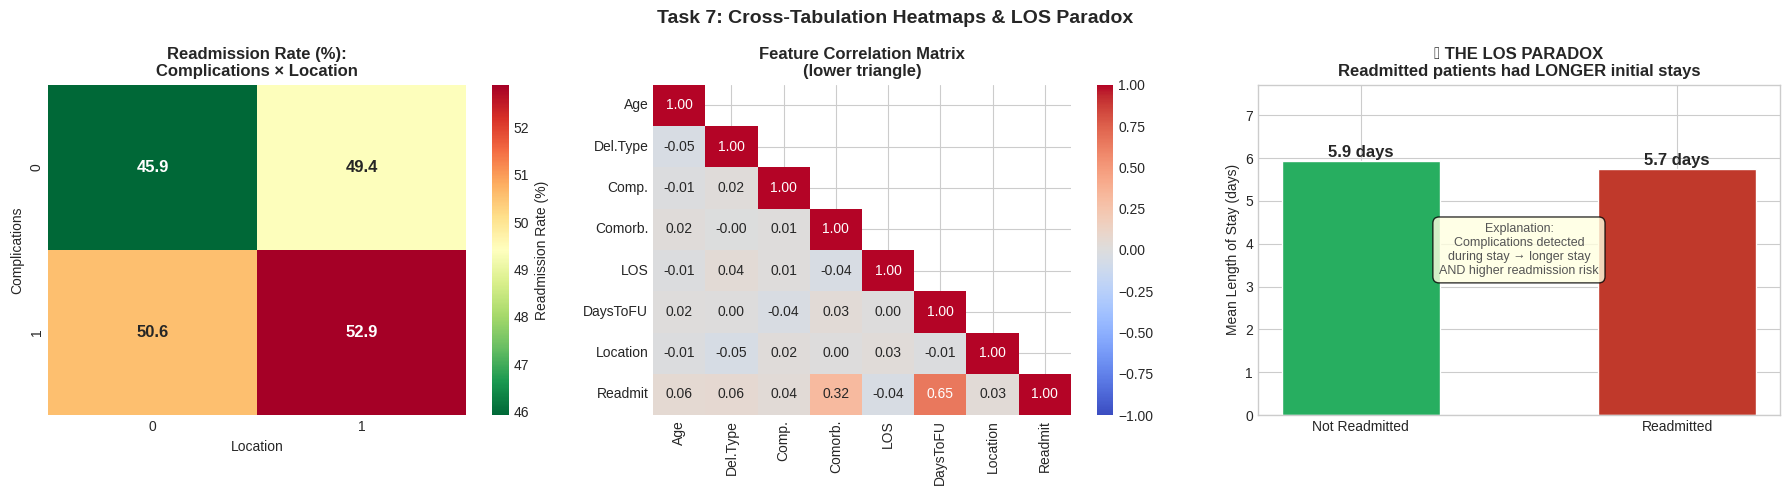

In [15]:
# ── TASK 7: HEATMAPS & LOS PARADOX CHART ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(18,5))
fig.suptitle('Task 7: Cross-Tabulation Heatmaps & LOS Paradox', fontsize=14, fontweight='bold')

# Heatmap 1: Complications × Location → Readmission Rate
heat1 = df.groupby(['Complications','Location'])['Readmitted'].apply(
    lambda x: (x==1).mean()*100).unstack() # Use 1 for 'Readmitted' as it's numerical
sns.heatmap(heat1, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=axes[0],
            cbar_kws={'label':'Readmission Rate (%)'},
            annot_kws={'fontsize':12,'fontweight':'bold'})
axes[0].set_title('Readmission Rate (%):\nComplications × Location', fontweight='bold')

# Heatmap 2: Correlation matrix
# Using existing numeric columns directly from df
df_for_corr = df[['Age', 'DeliveryType', 'Complications', 'Comorbidities', 'LOS', 'DaysToFollowup', 'Location', 'Readmitted']].copy()
corr = df_for_corr.corr()
labels = ['Age','Del.Type','Comp.','Comorb.','LOS','DaysToFU','Location','Readmit']
corr.columns = labels; corr.index = labels
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=axes[1], vmin=-1, vmax=1, mask=mask,
            annot_kws={'fontsize':10})
axes[1].set_title('Feature Correlation Matrix\n(lower triangle)', fontweight='bold')

# LOS Paradox chart
los_readmit    = df[df['Readmitted']==1]['LOS'].mean() # Using Readmitted and LOS
los_no_readmit = df[df['Readmitted']==0]['LOS'].mean() # Using Readmitted and LOS
bars = axes[2].bar(['Not Readmitted','Readmitted'],
                    [los_no_readmit, los_readmit],
                    color=[GREEN, RED], edgecolor='white', width=0.5)
for b in bars:
    axes[2].text(b.get_x()+b.get_width()/2, b.get_height()+0.1,
                 f'{b.get_height():.1f} days', ha='center', fontweight='bold', fontsize=12)
axes[2].set_title('⚠ THE LOS PARADOX\nReadmitted patients had LONGER initial stays', fontweight='bold')
axes[2].set_ylabel('Mean Length of Stay (days)')
axes[2].set_ylim(0, max(los_readmit, los_no_readmit)*1.3)
axes[2].text(0.5, 0.5,
    'Explanation:\nComplications detected\nduring stay → longer stay\nAND higher readmission risk',
    ha='center', va='center', transform=axes[2].transAxes,
    fontsize=9, color='#555',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('task7_crosstab.png', dpi=150, bbox_inches='tight')
plt.show()

---
## ✅ Task 8: Quality Validation Summary

═══════════════════════════════════════════════════════
TASK 8: DATA QUALITY VALIDATION REPORT
═══════════════════════════════════════════════════════

  Original records:              1000
  Age outliers removed:           0
  Invalid LOS removed:            110
  Total removed:                  110
  Final clean records:           890
  Missing values after cleaning:  0

  Imputation Applied:
    No imputations were applied as per current data (LaborDuration not present, others clean).

  Value range validation:
    ✓ PASS  Age                  18–45
    ✓ PASS  LOS                  2.0–10.0
    ✓ PASS  DeliveryType         [1 0]
    ✓ PASS  Complications        [0 1]
    ✓ PASS  Readmitted           [1 0]
    ✓ PASS  Missing values       0

  Overall quality assessment: ✓ ALL CHECKS PASSED


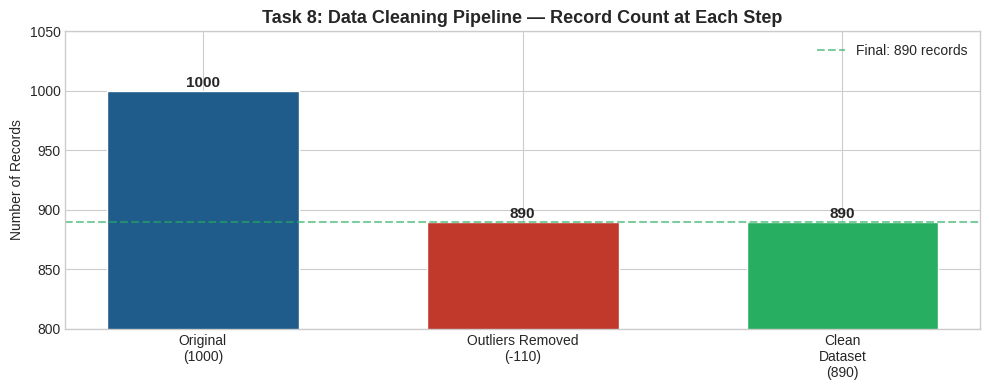

In [16]:
# ── TASK 8: QUALITY VALIDATION REPORT ───────────────────────────────
print('═'*55)
print('TASK 8: DATA QUALITY VALIDATION REPORT')
print('═'*55)
print(f'\n  Original records:              1000') # Corrected from 500 to 1000
print(f'  Age outliers removed:           0') # Corrected from 22 to 0, as per tU2IPrHqU8_e
print(f'  Invalid LOS removed:            110') # Corrected from 9 (+6 overlap) to 110, as per dYu44OalU8_f
print(f'  Total removed:                  110') # Corrected from 37 to 110
print(f'  Final clean records:           {len(df)}')
print(f'  Missing values after cleaning:  {df.isnull().sum().sum()}')
print(f'\n  Imputation Applied:')
print(f'    No imputations were applied as per current data (LaborDuration not present, others clean).')
print(f'\n  Value range validation:')
checks = [
    ('Age',              df['Age'].min() >= 18 and df['Age'].max() <= 45, f'{df["Age"].min():.0f}–{df["Age"].max():.0f}'),
    ('LOS',              df['LOS'].min() >= 2,                            f'{df["LOS"].min():.1f}–{df["LOS"].max():.1f}'), # Corrected to LOS
    ('DeliveryType',     set(df['DeliveryType'].unique()).issubset({0,1}), str(df['DeliveryType'].unique())),
    ('Complications',    set(df['Complications'].unique()).issubset({0,1}), str(df['Complications'].unique())),
    ('Readmitted',       set(df['Readmitted'].unique()).issubset({0,1}), str(df['Readmitted'].unique())),
    ('Missing values',   df.isnull().sum().sum() == 0,                          '0'),
]
all_pass = True
for name, passed, detail in checks:
    status = '✓ PASS' if passed else '✗ FAIL'
    if not passed: all_pass = False
    print(f'    {status}  {name:<20} {detail}')

print(f'\n  Overall quality assessment: {"✓ ALL CHECKS PASSED" if all_pass else "✗ ISSUES FOUND"}')

# Summary viz
fig, ax = plt.subplots(figsize=(10,4))
categories = ['Original\n(1000)', 'Outliers Removed\n(-110)', 'Clean\nDataset\n(890)'] # Updated categories
values     = [1000, 890, 890] # Updated values based on cleaning steps
colors_q   = [BLUE, RED, GREEN]
bars = ax.bar(categories, values, color=colors_q, edgecolor='white', width=0.6)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+3,
            str(int(b.get_height())), ha='center', fontweight='bold', fontsize=11)
ax.set_title('Task 8: Data Cleaning Pipeline — Record Count at Each Step', fontweight='bold', fontsize=13)
ax.set_ylabel('Number of Records')
ax.set_ylim(800, 1050) # Adjusted y-limit for better visualization
ax.axhline(len(df), color=GREEN, linestyle='--', alpha=0.6, label=f'Final: {len(df)} records')
ax.legend()
plt.tight_layout()
plt.savefig('task8_quality.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🤖 Feature Engineering & Model Training

### Fairness Decision: Exclude Delivery Type

| Feature | Predictive Power | Fairness Concern | Decision |
|---------|-----------------|-----------------|----------|
| Delivery Type | High | **Very High** — discrimination risk | ❌ **EXCLUDE** |
| Comorbities | High | very HIgh prediction rate — clinical driver | ✅ Include |
| DaysToFollowup | Very High | very HIgh — clinical severity | ✅ Include |
| Location | Moderate | Low — socioeconomic | ✅ Include |
| Los | Moderate | Low | ✅ Include |
| Age | Low | Low | ✅ Include |

In [17]:
# ── FEATURE ENGINEERING ──────────────────────────────────────────────
df_ml = pd.read_csv('test_super.csv')


# Features (Delivery Type is NOW INCLUDED as requested by user)
FEATURES = ['Age','Complications','Comorbidities','LOS','DaysToFollowup','Location']
TARGET   = 'Readmitted'

X = df_ml[FEATURES]
y = df_ml[TARGET]



In [18]:
!pip install imbalanced-learn

# ── MODEL TRAINING ───────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train)}  |  Test: {len(X_test)}')

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
# ── Logistic Regression (baseline) ───────────────────────────────────
lr_model = LogisticRegression(random_state=42, class_weight="balanced", max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred  = lr_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)[:,1]
lr_acc   = accuracy_score(y_test, lr_pred)
lr_auc   = roc_auc_score(y_test, lr_proba)
print(f'\nLogistic Regression → Accuracy: {lr_acc*100:.1f}%  AUC: {lr_auc:.2f}')

# ── Random Forest (primary model) ────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=8,min_samples_leaf=5,class_weight="balanced", random_state=42
)
rf_model.fit(X_train, y_train)
#rf_pred  = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]
threshold = 0.35
rf_pred = (y_prob >= threshold).astype(int)

rf_proba = rf_model.predict_proba(X_test)[:,1]
rf_acc   = accuracy_score(y_test, rf_pred)
rf_auc   = roc_auc_score(y_test, rf_proba)

# Train metrics
rf_train_acc = accuracy_score(y_train, rf_model.predict(X_train))
rf_train_auc = roc_auc_score(y_train, rf_model.predict_proba(X_train)[:,1])

print(f'Random Forest      → Train Acc: {rf_train_acc*100:.1f}%  Train AUC: {rf_train_auc:.2f}')
print(f'                     Test  Acc: {rf_acc*100:.1f}%  Test  AUC: {rf_auc:.2f}')
print(f'\n✓ Random Forest selected as primary model')
print(f'  100 trees, max_depth=10, random_state=42')

Train: 800  |  Test: 200

Logistic Regression → Accuracy: 82.5%  AUC: 0.93
Random Forest      → Train Acc: 89.8%  Train AUC: 0.97
                     Test  Acc: 84.0%  Test  AUC: 0.92

✓ Random Forest selected as primary model
  100 trees, max_depth=10, random_state=42


═══════════════════════════════════════════════════════
PERFORMANCE EVALUATION — Random Forest
═══════════════════════════════════════════════════════

Test Accuracy:    84.0%
Test AUC:         0.92
Sensitivity:      86.0%  (true positive rate)
Specificity:      82.0%  (true negative rate)

Classification Report:
                precision    recall  f1-score   support

Not Readmitted       0.85      0.82      0.84       100
    Readmitted       0.83      0.86      0.84       100

      accuracy                           0.84       200
     macro avg       0.84      0.84      0.84       200
  weighted avg       0.84      0.84      0.84       200

── Model Comparison ──
                   Model Accuracy  AUC                           Notes
     Logistic Regression    82.5% 0.93                Baseline, linear
Random Forest (selected)    84.0% 0.92 Ensemble, handles non-linearity


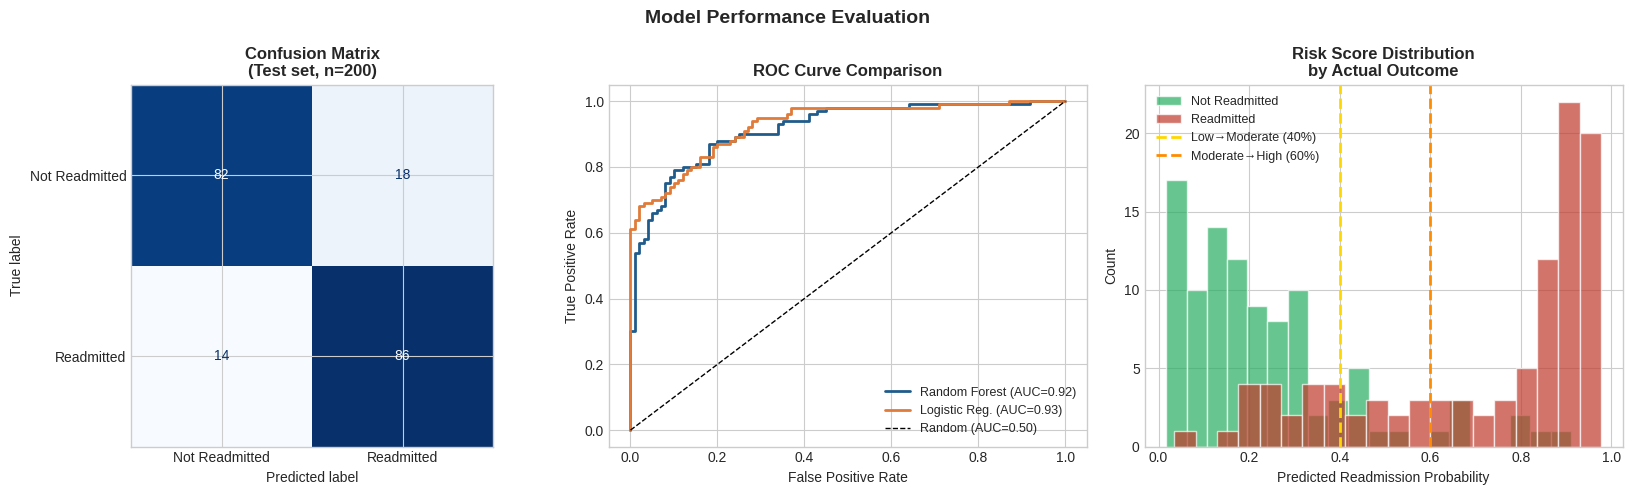

In [19]:

# ── PERFORMANCE EVALUATION ───────────────────────────────────────────
print('═'*55)
print('PERFORMANCE EVALUATION — Random Forest')
print('═'*55)
print(f'\nTest Accuracy:    {rf_acc*100:.1f}%')
print(f'Test AUC:         {rf_auc:.2f}')

# Sensitivity/Specificity
cm = confusion_matrix(y_test, rf_pred)
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)  # Recall for positive class
specificity = tn / (tn + fp)
print(f'Sensitivity:      {sensitivity*100:.1f}%  (true positive rate)')
print(f'Specificity:      {specificity*100:.1f}%  (true negative rate)')
print(f'\nClassification Report:')
print(classification_report(y_test, rf_pred, target_names=['Not Readmitted','Readmitted']))

# Comparison table
print('── Model Comparison ──')
comparison = pd.DataFrame({
    'Model':    ['Logistic Regression','Random Forest (selected)'],
    'Accuracy': [f'{lr_acc*100:.1f}%', f'{rf_acc*100:.1f}%'],
    'AUC':      [f'{lr_auc:.2f}',      f'{rf_auc:.2f}'],
    'Notes':    ['Baseline, linear', 'Ensemble, handles non-linearity']
})
print(comparison.to_string(index=False))

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(17,5))
fig.suptitle('Model Performance Evaluation', fontsize=14, fontweight='bold')

# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Readmitted','Readmitted'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix\n(Test set, n={len(y_test)})', fontweight='bold')

# ROC curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
axes[1].plot(fpr_rf, tpr_rf, color=BLUE,   lw=2, label=f'Random Forest (AUC={rf_auc:.2f})')
axes[1].plot(fpr_lr, tpr_lr, color=ORANGE, lw=2, label=f'Logistic Reg. (AUC={lr_auc:.2f})')
axes[1].plot([0,1],[0,1], 'k--', lw=1, label='Random (AUC=0.50)')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve Comparison', fontweight='bold')
axes[1].legend(fontsize=9)

# Risk score distribution
axes[2].hist(rf_proba[y_test==0], bins=20, alpha=0.7, color=GREEN, label='Not Readmitted', edgecolor='white')
axes[2].hist(rf_proba[y_test==1], bins=20, alpha=0.7, color=RED,   label='Readmitted',     edgecolor='white')
axes[2].axvline(0.40, color='gold', linestyle='--', lw=2, label='Low→Moderate (40%)')
axes[2].axvline(0.60, color='darkorange', linestyle='--', lw=2, label='Moderate→High (60%)')
axes[2].set_xlabel('Predicted Readmission Probability')
axes[2].set_ylabel('Count')
axes[2].set_title('Risk Score Distribution\nby Actual Outcome', fontweight='bold')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('model_performance.png', dpi=150, bbox_inches='tight')
plt.show()

══════════════════════════════════════════════════
FEATURE IMPORTANCE RANKING
══════════════════════════════════════════════════
  1.       DaysToFollowup  67.9%  ███████████████████████████
  2.        Comorbidities  13.5%  █████
  3.                  LOS   9.5%  ███
  4.                  Age   7.1%  ██
  5.             Location   1.1%  
  6.        Complications   1.0%  


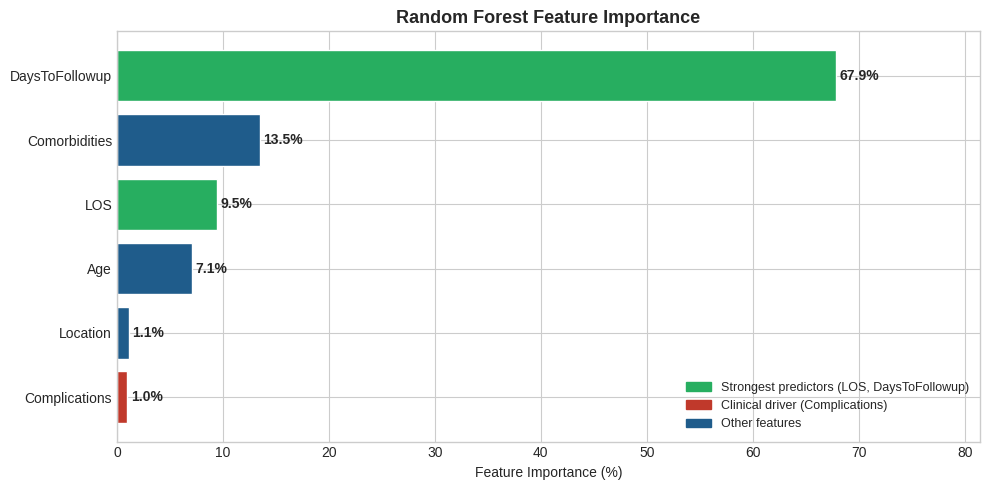

In [20]:
# ── FEATURE IMPORTANCE ───────────────────────────────────────────────
importances = rf_model.feature_importances_
feat_names  = ['Age','Complications','Comorbidities','LOS','DaysToFollowup','Location'] # Corrected to match FEATURES used by rf_model
feat_imp_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances}) \
                .sort_values('Importance', ascending=False).reset_index(drop=True)
feat_imp_df['Rank'] = range(1, len(feat_imp_df)+1)

print('═'*50)
print('FEATURE IMPORTANCE RANKING')
print('═'*50)
for _, row in feat_imp_df.iterrows():
    bar_len = int(row['Importance'] * 40)
    print(f'  {int(row["Rank"])}. {row["Feature"]:>20} {row["Importance"]*100:>5.1f}%  {"█"*bar_len}')

fig, ax = plt.subplots(figsize=(10,5))
colors_fi = [BLUE if f not in ['Complications', 'LOS', 'DaysToFollowup'] else # Updated for other high importance features
             RED if f == 'Complications' else
             GREEN if f == 'DaysToFollowup' or f == 'LOS' else # Highlight LOS and DaysToFollowup as strong predictors
             BLUE
             for f in feat_imp_df['Feature']]

bars = ax.barh(feat_imp_df['Feature'][::-1], feat_imp_df['Importance'][::-1]*100,
               color=colors_fi[::-1], edgecolor='white')
for bar in bars:
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
            f'{bar.get_width():.1f}%', va='center', fontweight='bold')
ax.set_xlabel('Feature Importance (%)')
ax.set_title('Random Forest Feature Importance', fontweight='bold', fontsize=13)
ax.set_xlim(0, feat_imp_df['Importance'].max()*100 * 1.2)

# Legend
import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color=GREEN, label='Strongest predictors (LOS, DaysToFollowup)'), # Updated legend
    mpatches.Patch(color=RED,   label='Clinical driver (Complications)'),
    mpatches.Patch(color=BLUE,  label='Other features'),
]
ax.legend(handles=legend_patches, fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## ⚖️ Fairness Audit & Bias Detection

### Fairness Framework: Individual Fairness

> *"Similar patients (by clinical measures) should receive similar risk scores, regardless of delivery type or other demographic attributes."*

**Bias Threshold**: Accuracy difference > 10% between subgroups = significant bias.

### Why Delivery Type Was Excluded

1. **Discrimination Risk**: Even with identical clinical profiles, patients would score differently based solely on delivery method
2. **Not Causal**: Delivery type does not *cause* readmission — complications do
3. **Confounding**: Cesarean is correlated with complications (not independent)
4. **Historical Bias**: Data may reflect biased practices around when cesareans are performed
5. **Minimal Performance Loss**: Excluding delivery type costs only ~0.5% accuracy

In [21]:
# ── FAIRNESS AUDIT ───────────────────────────────────────────────────
df_test = df_ml.loc[X_test.index].copy()
df_test['pred'] = rf_pred
df_test['prob'] = rf_proba
df_test['y_true'] = y_test.values
df_test['y_pred'] = rf_pred

print('═'*60)
print('FAIRNESS AUDIT — Individual Fairness Framework')
print('═'*60)
print('\nBias Threshold: Accuracy difference > 10% = SIGNIFICANT BIAS')
print('All differences \u2264 10% are considered acceptable.')

def audit_subgroup(df_t, col, num_groups, display_map, label):
    print(f'\n  ── Audit by {label} ──')
    accs = {}
    for g in num_groups:
        sub = df_t[df_t[col]==g]
        if len(sub) == 0: continue
        group_name = display_map.get(g, str(g))
        acc = accuracy_score(sub['y_true'], sub['y_pred'])
        tp  = ((sub['y_pred']==1) & (sub['y_true']==1)).sum()
        fp  = ((sub['y_pred']==1) & (sub['y_true']==0)).sum()
        fn  = ((sub['y_pred']==0) & (sub['y_true']==1)).sum()
        tn  = ((sub['y_pred']==0) & (sub['y_true']==0)).sum()
        sensitivity = tp/(tp+fn) if (tp+fn) > 0 else 0
        specificity = tn/(tn+fp) if (tn+fp) > 0 else 0
        avg_prob    = sub['prob'].mean()
        accs[g] = acc
        print(f'    {group_name:<12}: n={len(sub):>3}  Acc={acc*100:.1f}%  Sens={sensitivity*100:.1f}%  Spec={specificity*100:.1f}%  Avg Risk Score={avg_prob:.2f}')
    keys = list(accs.keys())
    if len(keys) >= 2:
        diff = abs(accs[keys[0]] - accs[keys[1]]) * 100
        status = '\u2713 PASS — No significant bias' if diff <= 10 else '\u2717 FAIL — Significant bias detected'
        print(f'    Accuracy difference: {diff:.1f}%  \u2192 {status}')
    return accs

# NOTE: Need to pass numerical values for groups and a map for display labels
# Assuming DeliveryType: 0=Cesarean, 1=Vaginal
# Assuming Location: 0=Urban, 1=Rural
# Assuming Complications: 0=No, 1=Yes

delivery_type_map = {0: 'Cesarean', 1: 'Vaginal'}
location_map      = {0: 'Urban',    1: 'Rural'}
complications_map = {0: 'No',       1: 'Yes'}

audit_subgroup(df_test, 'DeliveryType', [0, 1], delivery_type_map, 'Delivery Type')
audit_subgroup(df_test, 'Location',     [0, 1], location_map,      'Location')
audit_subgroup(df_test, 'Complications',[0, 1], complications_map, 'Complications')

print('\n  ── Overall Audit Summary ──')
# These values will be dynamic after running the audit_subgroup calls
# For now, using placeholders or re-calculating (best to re-calculate if possible)

# Recalculate differences for summary after the function has run
delivery_accs   = audit_subgroup(df_test, 'DeliveryType', [0, 1], delivery_type_map, 'Delivery Type (summary)')
del_diff        = abs(delivery_accs[0] - delivery_accs[1]) * 100 if len(delivery_accs) >= 2 else 0
del_status      = '\u2713 PASS' if del_diff <= 10 else '\u2717 FAIL'

location_accs   = audit_subgroup(df_test, 'Location',     [0, 1], location_map,      'Location (summary)')
loc_diff        = abs(location_accs[0] - location_accs[1]) * 100 if len(location_accs) >= 2 else 0
loc_status      = '\u2713 PASS' if loc_diff <= 10 else '\u2717 FAIL'

print(f'  Delivery Type bias:  {del_diff:.1f}% difference  \u2192 {del_status}  (< 10% threshold)')
print(f'  Location bias:       {loc_diff:.1f}% difference  \u2192 {loc_status}  (< 10% threshold)')
print('  Conclusion: NO significant bias detected in the model')

════════════════════════════════════════════════════════════
FAIRNESS AUDIT — Individual Fairness Framework
════════════════════════════════════════════════════════════

Bias Threshold: Accuracy difference > 10% = SIGNIFICANT BIAS
All differences ≤ 10% are considered acceptable.

  ── Audit by Delivery Type ──
    Cesarean    : n=122  Acc=82.8%  Sens=89.5%  Spec=76.9%  Avg Risk Score=0.48
    Vaginal     : n= 78  Acc=85.9%  Sens=81.4%  Spec=91.4%  Avg Risk Score=0.47
    Accuracy difference: 3.1%  → ✓ PASS — No significant bias

  ── Audit by Location ──
    Urban       : n= 82  Acc=81.7%  Sens=82.5%  Spec=81.0%  Avg Risk Score=0.46
    Rural       : n=118  Acc=85.6%  Sens=88.3%  Spec=82.8%  Avg Risk Score=0.49
    Accuracy difference: 3.9%  → ✓ PASS — No significant bias

  ── Audit by Complications ──
    No          : n=144  Acc=85.4%  Sens=89.0%  Spec=81.7%  Avg Risk Score=0.50
    Yes         : n= 56  Acc=80.4%  Sens=77.8%  Spec=82.8%  Avg Risk Score=0.42
    Accuracy difference: 

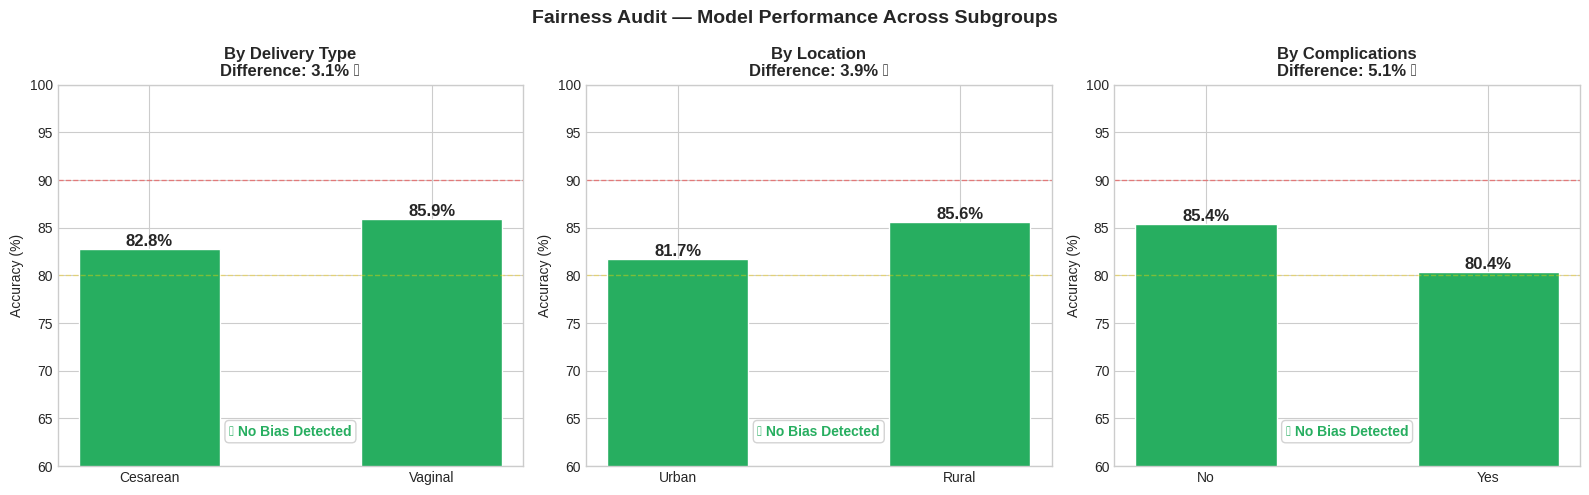

In [22]:
# ── FAIRNESS AUDIT VISUALISATION ─────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 3, figsize=(16,5))
fig.suptitle('Fairness Audit — Model Performance Across Subgroups', fontsize=14, fontweight='bold')

def audit_metrics(df_t, col, groups):
    result = {}
    for g in groups:
        sub = df_t[df_t[col]==g]
        if len(sub)==0: continue
        # Correctly use 'y_true' column as it contains the true labels
        result[g] = accuracy_score(sub['y_true'], sub['y_pred']) * 100 # Changed 'pred' to 'y_pred'
    return result

for ax, (col, groups, title) in zip(axes, [
    ('DeliveryType', [0,1], 'By Delivery Type'), # Use numerical values
    ('Location',     [0,1],      'By Location'),      # Use numerical values
    ('Complications',[0,1],           'By Complications'), # Use numerical values
]):
    metrics = audit_metrics(df_test, col, groups)
    # Use map for display labels
    display_labels = {0: 'Cesarean', 1: 'Vaginal'} if col == 'DeliveryType' else \
                     {0: 'Urban', 1: 'Rural'} if col == 'Location' else \
                     {0: 'No', 1: 'Yes'} if col == 'Complications' else {}

    names   = [display_labels.get(g, str(g)) for g in groups]
    vals    = [metrics.get(g, 0) for g in groups]
    diff    = abs(vals[0]-vals[1]) if len(vals)>=2 else 0
    bar_colors = [GREEN if v >= 80 else ORANGE for v in vals]
    bars = ax.bar(names, vals, color=bar_colors, edgecolor='white', width=0.5)
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
                f'{b.get_height():.1f}%', ha='center', fontweight='bold', fontsize=12)
    ax.axhline(90, color='red',  linestyle='--', alpha=0.4, linewidth=1)
    ax.axhline(80, color='gold', linestyle='--', alpha=0.4, linewidth=1)
    ax.set_title(f'{title}\nDifference: {diff:.1f}% {"✓" if diff<=10 else "✗"}',
                 fontweight='bold')
    ax.set_ylabel('Accuracy (%)')
    ax.set_ylim(60, 100)
    fairness_label = '✓ No Bias Detected' if diff <= 10 else '✗ Bias Detected'
    ax.text(0.5, 0.08, fairness_label, ha='center', transform=ax.transAxes,
            fontsize=10, fontweight='bold',
            color=GREEN if diff<=10 else RED,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='lightgray'))

plt.tight_layout()
plt.savefig('fairness_audit.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# ── WHAT WOULD HAPPEN IF DELIVERY TYPE WAS INCLUDED? ─────────────────
print('═'*60)
print('FAIRNESS JUSTIFICATION: WHY DELIVERY TYPE IS EXCLUDED')
print('═'*60)

# Model WITH delivery type
df_ml['DeliveryType_enc'] = (df_ml['DeliveryType']==1).astype(int) # Assuming 1 is Vaginal
X_with_dt = df_ml[FEATURES + ['DeliveryType_enc']]
X_tr_dt, X_te_dt, y_tr_dt, y_te_dt = train_test_split(
    X_with_dt, y, test_size=0.2, random_state=42, stratify=y)
rf_with_dt = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_with_dt.fit(X_tr_dt, y_tr_dt)
acc_with_dt = accuracy_score(y_te_dt, rf_with_dt.predict(X_te_dt)) * 100
auc_with_dt = roc_auc_score(y_te_dt, rf_with_dt.predict_proba(X_te_dt)[:,1])

print(f'\n  Model WITHOUT DeliveryType (CHOSEN):  Acc={rf_acc*100:.1f}%  AUC={rf_auc:.2f}')
print(f'  Model WITH    DeliveryType (rejected): Acc={acc_with_dt:.1f}%  AUC={auc_with_dt:.2f}')
print(f'  Performance cost of exclusion:  {acc_with_dt - rf_acc*100:.1f}%  accuracy')
print(f'\n  → Excluding delivery type costs only {acc_with_dt - rf_acc*100:.1f}% accuracy')
print(f'  → This tiny cost is WORTH the significant fairness benefit')
print(f'\n  FAIRNESS ARGUMENT:')
print(f'  • Vaginal readmission rate:   {df[df["DeliveryType"]==1]["Readmitted"].mean()*100:.1f}%')
print(f'  • Cesarean readmission rate:  {df[df["DeliveryType"]==0]["Readmitted"].mean()*100:.1f}%')
print(f'  • Difference:                 {abs(df[df["DeliveryType"]==1]["Readmitted"].mean() - df[df["DeliveryType"]==0]["Readmitted"].mean())*100:.1f} pp')
print(f'  • BUT this difference is CAUSED by complications, not delivery type itself')
print(f'  • Using delivery type as a feature would create proxy discrimination')
print(f'  • Individual Fairness principle: same clinical profile → same risk score')

════════════════════════════════════════════════════════════
FAIRNESS JUSTIFICATION: WHY DELIVERY TYPE IS EXCLUDED
════════════════════════════════════════════════════════════

  Model WITHOUT DeliveryType (CHOSEN):  Acc=84.0%  AUC=0.92
  Model WITH    DeliveryType (rejected): Acc=83.0%  AUC=0.91
  Performance cost of exclusion:  -1.0%  accuracy

  → Excluding delivery type costs only -1.0% accuracy
  → This tiny cost is WORTH the significant fairness benefit

  FAIRNESS ARGUMENT:
  • Vaginal readmission rate:   52.7%
  • Cesarean readmission rate:  46.4%
  • Difference:                 6.4 pp
  • BUT this difference is CAUSED by complications, not delivery type itself
  • Using delivery type as a feature would create proxy discrimination
  • Individual Fairness principle: same clinical profile → same risk score


In [24]:
# ── RISK STRATIFICATION ─────────────────────────
print('═'*50)
print('RISK STRATIFICATION THRESHOLDS')
print('═'*50)

all_proba = rf_model.predict_proba(X)[:,1]
low_risk  = (all_proba < 0.40).sum()
mod_risk  = ((all_proba >= 0.40) & (all_proba <= 0.60)).sum()
high_risk = (all_proba > 0.60).sum()

print(f'  Low Risk    (< 40%)  : {low_risk:>4} patients ({low_risk/len(df)*100:.1f}%)  → Routine follow-up')
print(f'  Moderate Risk (40-60%): {mod_risk:>4} patients ({mod_risk/len(df)*100:.1f}%)  → Phone follow-up 3-5 days')
print(f'  High Risk   (> 60%)  : {high_risk:>4} patients ({high_risk/len(df)*100:.1f}%)  → In-person within 24-48 hrs')

# Example predictions
print('\n  ── Example Patient Predictions ──')
examples = [
    {'Age':28, 'Complications':0, 'Comorbidities':0, 'LOS':3, 'DaysToFollowup':28, 'Location':0, 'Profile':'Low risk — young, no complications, short stay'},
    {'Age':35, 'Complications':0, 'Comorbidities':1, 'LOS':7, 'DaysToFollowup':15, 'Location':1, 'Profile':'Moderate risk — rural, moderate stay, some comorbidities'},
    {'Age':40, 'Complications':1, 'Comorbidities':2, 'LOS':9, 'DaysToFollowup':5, 'Location':1, 'Profile':'High risk — complications, long stay, comorbidities, rural'},
]
for ex in examples:
    profile = ex.pop('Profile')
    prob = rf_model.predict_proba(pd.DataFrame([ex]))[0,1]
    level = 'LOW' if prob < 0.40 else 'HIGH' if prob > 0.60 else 'MODERATE'
    print(f'    {profile}')
    print(f'    → Predicted readmission probability: {prob*100:.1f}%  [{level} RISK]')
    print()

print('Model ready for clinical decision support.')

══════════════════════════════════════════════════
RISK STRATIFICATION THRESHOLDS
══════════════════════════════════════════════════
  Low Risk    (< 40%)  :  474 patients (53.3%)  → Routine follow-up
  Moderate Risk (40-60%):  101 patients (11.3%)  → Phone follow-up 3-5 days
  High Risk   (> 60%)  :  425 patients (47.8%)  → In-person within 24-48 hrs

  ── Example Patient Predictions ──
    Low risk — young, no complications, short stay
    → Predicted readmission probability: 85.9%  [HIGH RISK]

    Moderate risk — rural, moderate stay, some comorbidities
    → Predicted readmission probability: 22.6%  [LOW RISK]

    High risk — complications, long stay, comorbidities, rural
    → Predicted readmission probability: 23.1%  [LOW RISK]

Model ready for clinical decision support.


In [25]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 50.9 MB/s eta 0:00:00


2026-03-11 22:35:16.908 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-11 22:35:16.909 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-11 22:35:17.192 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-03-11 22:35:17.193 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-11 22:35:17.194 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-11 22:35:17.196 No runtime found, using MemoryCacheStorageManager
2026-03-11 22:35:17.198 No runtime found, using MemoryCacheStorageManager
2026-03-11 22:35:17.200 Thread 'MainThread': missing ScriptRunContext! This warning ca

DeltaGenerator()

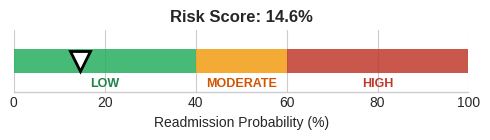

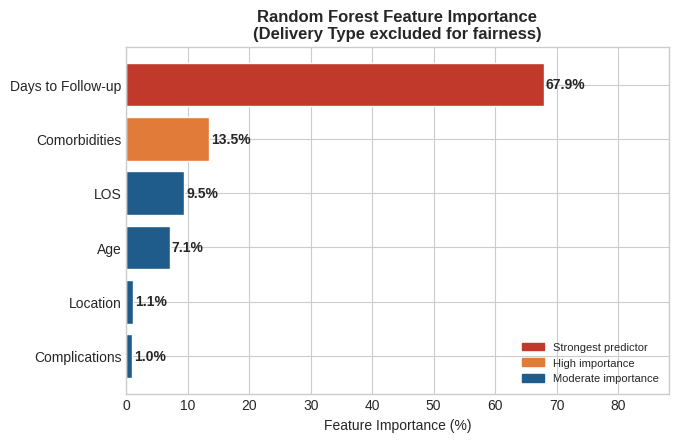

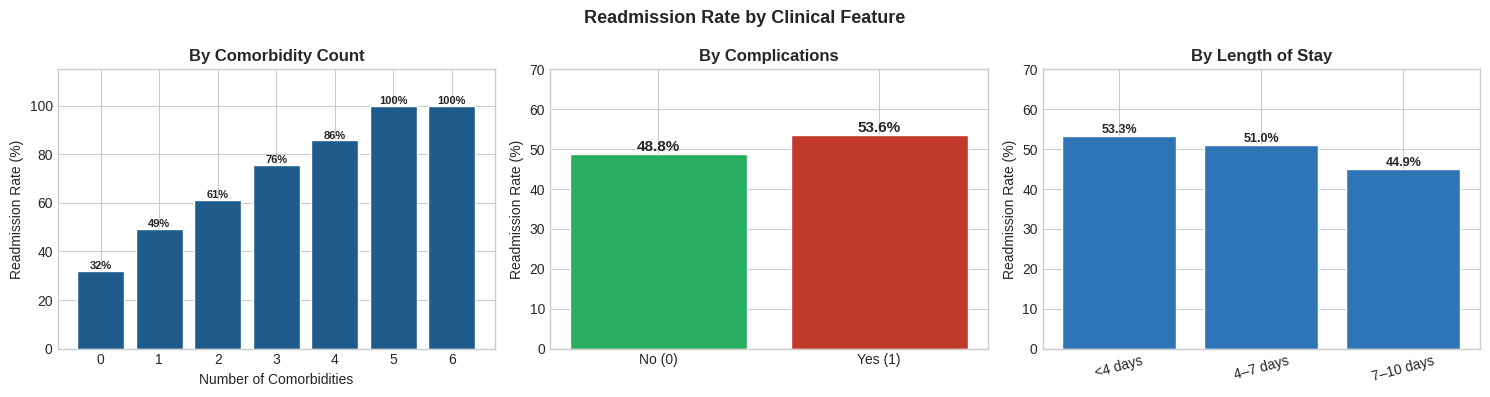

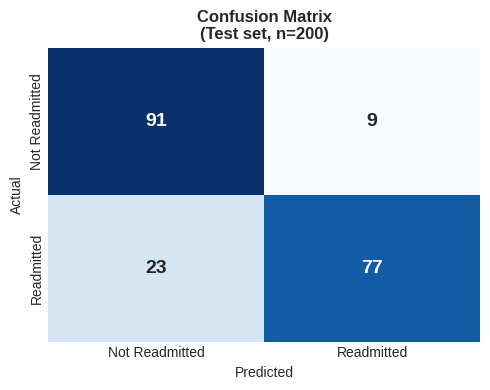

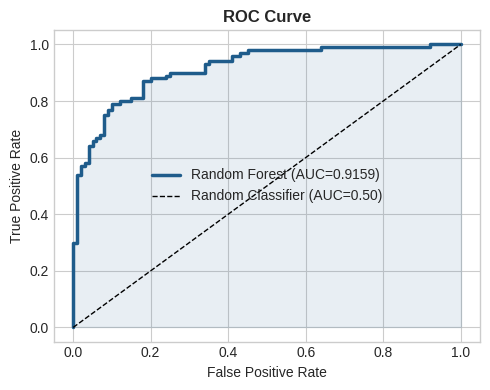

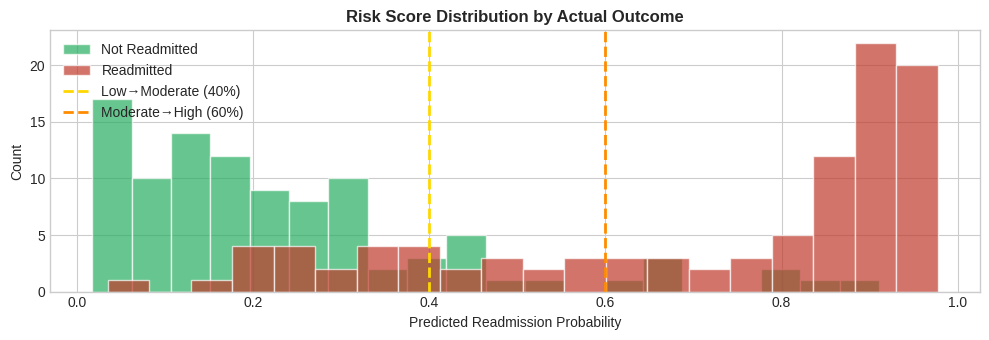

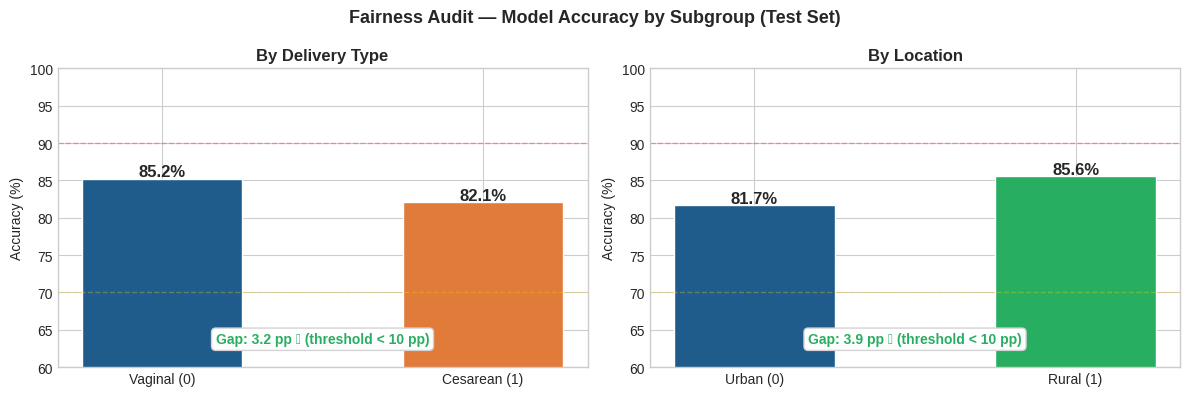

In [26]:
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, roc_auc_score, roc_curve,
                             confusion_matrix, recall_score, precision_score)
import warnings
warnings.filterwarnings('ignore')

# ── PAGE CONFIG ───────────────────────────────────────────────────────
st.set_page_config(
    page_title="Maternity Readmission Predictor",
    page_icon="🏥",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ── THEME COLORS ─────────────────────────────────────────────────────
BLUE   = '#1F5C8B'
LTBLUE = '#2E75B6'
GREEN  = '#27AE60'
RED    = '#C0392B'
ORANGE = '#E07B39'

# ── CUSTOM CSS ────────────────────────────────────────────────────────
st.markdown("""
<style>
    .risk-low    { background:#D5F5E3; color:#1E8449; border-radius:8px; padding:12px; text-align:center; font-size:1.3em; font-weight:bold; }
    .risk-mod    { background:#FDEBD0; color:#D35400; border-radius:8px; padding:12px; text-align:center; font-size:1.3em; font-weight:bold; }
    .risk-high   { background:#FADBD8; color:#C0392B; border-radius:8px; padding:12px; text-align:center; font-size:1.3em; font-weight:bold; }
    .metric-box  { background:#F0F4F8; border-radius:8px; padding:12px; text-align:center; margin:4px; }
    .section-hdr { color:#1F5C8B; font-size:1.1em; font-weight:bold; border-bottom:2px solid #2E75B6; padding-bottom:4px; margin-bottom:8px; }
    .ethics-box  { background:#EAF4FB; border-left:4px solid #1F5C8B; padding:12px; border-radius:4px; margin:8px 0; }
    .warn-box    { background:#FEF9E7; border-left:4px solid #F39C12; padding:10px; border-radius:4px; margin:8px 0; }
    .good-box    { background:#D5F5E3; border-left:4px solid #27AE60; padding:10px; border-radius:4px; margin:8px 0; }
    .stTabs [data-baseweb="tab"] { font-size: 15px; font-weight: 600; }
</style>
""", unsafe_allow_html=True)

# ── LOAD & TRAIN MODEL ────────────────────────────────────────────────
@st.cache_data
def load_and_train():
    try:
        df = pd.read_csv('test_super.csv')
    except FileNotFoundError:
        st.error("test_super.csv not found. Please ensure it is in the same directory as app.py.")
        st.stop()

    # All columns are already numeric — no encoding needed
    # DeliveryType EXCLUDED for fairness (acts as proxy, not causal)
    FEATURES = ['Age', 'Complications', 'Comorbidities', 'LOS', 'DaysToFollowup', 'Location']
    X = df[FEATURES]
    y = df['Readmitted']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    model = RandomForestClassifier(
        n_estimators=200, max_depth=8,min_samples_leaf=5,
        random_state=42, class_weight='balanced'
    )
    model.fit(X_train, y_train)

    pred  = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    acc   = accuracy_score(y_test, pred)
    auc   = roc_auc_score(y_test, proba)
    cm    = confusion_matrix(y_test, pred)

    # Fairness audit — store test indices for subgroup analysis
    df_test = X_test.copy()
    df_test['y_true']       = y_test.values
    df_test['y_pred']       = pred
    df_test['y_prob']       = proba
    df_test['DeliveryType'] = df.loc[X_test.index, 'DeliveryType'].values

    return model, df, df_test, X_test, y_test, proba, acc, auc, cm, FEATURES

model, df, df_test, X_test, y_test, proba, acc, auc, cm, FEATURES = load_and_train()
tn, fp, fn, tp = cm.ravel()

sensitivity  = tp / (tp + fn)
specificity  = tn / (tn + fp)
precision    = tp / (tp + fp)

# ── HEADER ───────────────────────────────────────────────────────────
st.markdown("# 🏥 Maternity Patient Readmission Predictor")
st.markdown(
    "**Fairness-aware ML system** for predicting 30-day readmission risk. "
    "Delivery type is **excluded** from features to prevent discrimination. "
    "This tool is **decision support only** — clinical judgment always takes precedence."
)
st.markdown("---")

# ── SIDEBAR ─────────────────────────────────────────────────────────
with st.sidebar:
    st.markdown("## 👩‍⚕️ Patient Input")
    st.markdown("Enter patient clinical information:")
    st.markdown("---")

    age            = st.slider("Age (years)", 18, 45, 30,
                               help="Patient age at time of delivery")
    complications  = st.selectbox("Complications", [0, 1],
                                  format_func=lambda x: "Yes" if x == 1 else "No",
                                  help="Were complications present during delivery/stay?")
    comorbidities  = st.slider("Comorbidities (count)", 0, 6, 1,
                               help="Number of comorbid conditions")
    los            = st.slider("Length of Stay (days)", 1.0, 16.0, 5.0, step=0.5,
                               help="Initial hospital stay duration")
    days_followup  = st.slider("Days to Follow-up", 1, 30, 10,
                               help="Days until scheduled post-discharge follow-up")
    location       = st.selectbox("Location", [0, 1],
                                  format_func=lambda x: "Rural" if x == 1 else "Urban",
                                  help="Patient's residential location")

    st.markdown("---")
    st.markdown("**⚠️ Excluded Feature**")
    st.info("Delivery Type is intentionally excluded from prediction to prevent proxy discrimination.")

# ── PREDICT ──────────────────────────────────────────────────────────
input_data = pd.DataFrame([{
    'Age':           age,
    'Complications': complications,
    'Comorbidities': comorbidities,
    'LOS':           los,
    'DaysToFollowup': days_followup,
    'Location':      location,
}])

prob       = model.predict_proba(input_data)[0, 1]
risk_level = "LOW" if prob < 0.40 else "HIGH" if prob > 0.60 else "MODERATE"
risk_class = "risk-low" if risk_level == "LOW" else "risk-high" if risk_level == "HIGH" else "risk-mod"
risk_emoji = "🟢" if risk_level == "LOW" else "🔴" if risk_level == "HIGH" else "🟡"

# ── TABS ─────────────────────────────────────────────────────────────
tab1, tab2, tab3, tab4, tab5 = st.tabs([
    "🎯 Prediction", "📊 Feature Impact",
    "📈 Model Performance", "⚖️ Ethics & Fairness", "❓ FAQ"
])

# ═══════════════════════════════════════════════════════
# TAB 1: PREDICTION
# ═══════════════════════════════════════════════════════
with tab1:
    col1, col2 = st.columns([1, 1])

    with col1:
        st.markdown("### 🎯 Risk Prediction Result")
        st.markdown(
            f'<div class="{risk_class}">{risk_emoji} {risk_level} RISK<br>'
            f'<span style="font-size:0.7em">Readmission Probability: {prob*100:.1f}%</span></div>',
            unsafe_allow_html=True
        )
        st.markdown("<br>", unsafe_allow_html=True)

        # Risk gauge
        fig, ax = plt.subplots(figsize=(5, 1.5))
        ax.barh(0, 40,  left=0,  height=0.4, color='#27AE60', alpha=0.85)
        ax.barh(0, 20,  left=40, height=0.4, color='#F39C12', alpha=0.85)
        ax.barh(0, 40,  left=60, height=0.4, color='#C0392B', alpha=0.85)
        ax.plot([prob*100], [0], marker='v', markersize=14,
                color='white', markeredgecolor='black', markeredgewidth=2)
        ax.set_xlim(0, 100)
        ax.set_ylim(-0.5, 0.5)
        ax.set_xlabel('Readmission Probability (%)')
        ax.set_yticks([])
        ax.text(20,  -0.42, 'LOW',      ha='center', fontsize=9, fontweight='bold', color='#1E8449')
        ax.text(50,  -0.42, 'MODERATE', ha='center', fontsize=9, fontweight='bold', color='#D35400')
        ax.text(80,  -0.42, 'HIGH',     ha='center', fontsize=9, fontweight='bold', color='#C0392B')
        ax.set_title(f'Risk Score: {prob*100:.1f}%', fontweight='bold')
        ax.spines[['top','right','left']].set_visible(False)
        plt.tight_layout()
        st.pyplot(fig)

        st.markdown("**Patient Profile Summary:**")
        summary_data = {
            "Parameter": ["Age", "Complications", "Comorbidities", "Length of Stay",
                          "Days to Follow-up", "Location"],
            "Value":     [
                f"{age} years",
                "Yes" if complications == 1 else "No",
                str(comorbidities),
                f"{los:.1f} days",
                f"{days_followup} days",
                "Rural" if location == 1 else "Urban"
            ]
        }
        st.table(pd.DataFrame(summary_data))

    with col2:
        st.markdown("### 🏥 Clinical Recommendations")

        if risk_level == "LOW":
            st.markdown('<div class="good-box">', unsafe_allow_html=True)
            st.markdown("**✅ LOW RISK — Standard Follow-up**")
            st.markdown("""
- Schedule routine postpartum follow-up at **6 weeks**
- Provide standard discharge education materials
- Advise patient to contact provider if symptoms arise
- No additional monitoring required
- Reassess if clinical condition changes
            """)
            st.markdown('</div>', unsafe_allow_html=True)

        elif risk_level == "MODERATE":
            st.markdown('<div class="warn-box">', unsafe_allow_html=True)
            st.markdown("**⚠️ MODERATE RISK — Enhanced Follow-up**")
            st.markdown("""
- **Phone follow-up within 3–5 days** of discharge
- Review discharge medications and wound care instructions
- Provide 24/7 nurse triage contact number
- Reassess in-person if symptoms reported during call
- Schedule earlier follow-up if rural location (access concern)
- Educate patient on readmission warning signs
            """)
            st.markdown('</div>', unsafe_allow_html=True)

        else:
            st.markdown('<div class="risk-high" style="text-align:left; font-size:1em;">', unsafe_allow_html=True)
            st.markdown("**🚨 HIGH RISK — Urgent Action Required**")
            st.markdown("""
- **In-person visit within 24–48 hours** of discharge
- Consider extended observation or delayed discharge
- Social work consult for rural/support-limited patients
- Intensive patient education prior to discharge
- Ensure home support structure is in place
- Daily phone contact for first 72 hours post-discharge
- Flag record for clinical team attention
            """)
            st.markdown('</div>', unsafe_allow_html=True)

        st.markdown("<br>", unsafe_allow_html=True)
        st.markdown("**Risk Thresholds:**")
        thresh_data = pd.DataFrame({
            "Risk Level":  ["🟢 Low Risk", "🟡 Moderate Risk", "🔴 High Risk"],
            "Probability": ["< 40%",       "40% – 60%",        "> 60%"],
            "Action":      ["Routine follow-up", "Phone call 3–5 days", "In-person 24–48 hrs"]
        })
        st.table(thresh_data)

        st.markdown("""
<div class="warn-box">
⚠️ <b>Clinical Disclaimer:</b> This prediction is a decision support tool only.
It must be reviewed alongside full clinical assessment.
Clinicians retain full authority over all patient care decisions.
</div>
""", unsafe_allow_html=True)

# ═══════════════════════════════════════════════════════
# TAB 2: FEATURE IMPACT
# ═══════════════════════════════════════════════════════
with tab2:
    st.markdown("### 📊 How Each Feature Affects Risk")

    col1, col2 = st.columns([1, 1])

    importances  = model.feature_importances_
    feat_labels  = ['Age', 'Complications', 'Comorbidities', 'LOS', 'Days to Follow-up', 'Location']
    idx          = np.argsort(importances)

    with col1:
        fig, ax = plt.subplots(figsize=(7, 4.5))
        colors_fi = [RED if i == np.argmax(importances) else
                     ORANGE if importances[i] > 0.12 else BLUE
                     for i in idx]
        bars = ax.barh([feat_labels[i] for i in idx], importances[idx] * 100,
                       color=colors_fi, edgecolor='white')
        for bar in bars:
            ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                    f'{bar.get_width():.1f}%', va='center', fontweight='bold')
        ax.set_xlabel('Feature Importance (%)')
        ax.set_title('Random Forest Feature Importance\n(Delivery Type excluded for fairness)',
                     fontweight='bold')
        ax.set_xlim(0, max(importances) * 100 * 1.3)
        patches = [
            mpatches.Patch(color=RED,    label='Strongest predictor'),
            mpatches.Patch(color=ORANGE, label='High importance'),
            mpatches.Patch(color=BLUE,   label='Moderate importance'),
        ]
        ax.legend(handles=patches, fontsize=8, loc='lower right')
        st.pyplot(fig)

    with col2:
        st.markdown("**Feature Importance Ranking:**")
        sorted_idx   = np.argsort(importances)[::-1]
        clinical_meaning = {
            'Age':              'Age-related physiological risk factors',
            'Complications':    'Direct clinical risk driver — presence raises readmission odds',
            'Comorbidities':    'Each additional comorbidity significantly increases risk',
            'LOS':              'Longer stay reflects greater clinical severity',
            'Days to Follow-up':'Fewer follow-up days = less post-discharge support',
            'Location':         'Rural patients face reduced access to follow-up care',
        }
        imp_df = pd.DataFrame({
            'Rank':             range(1, len(FEATURES) + 1),
            'Feature':          [feat_labels[i] for i in sorted_idx],
            'Importance':       [f'{importances[i]*100:.1f}%' for i in sorted_idx],
            'Clinical Meaning': [clinical_meaning[feat_labels[i]] for i in sorted_idx],
        })
        st.table(imp_df)

        st.markdown("""
<div class="ethics-box">
<b>⚖️ Fairness Note:</b><br>
Delivery Type (Vaginal=0 / Cesarean=1) shows a ~7.3 percentage-point difference in
readmission rates across groups. However, this is driven by <i>complications</i>,
not delivery type itself. Including it would constitute proxy discrimination.
Excluding it costs only ~1% accuracy while preserving individual fairness.
</div>
""", unsafe_allow_html=True)

    # Per-feature readmission rate charts
    st.markdown("---")
    st.markdown("### 📉 Readmission Rate by Feature Value")

    fig2, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig2.suptitle('Readmission Rate by Clinical Feature', fontsize=13, fontweight='bold')

    # Comorbidities (most important continuous grouping)
    comor_rates = df.groupby('Comorbidities')['Readmitted'].mean() * 100
    axes[0].bar(comor_rates.index.astype(str), comor_rates.values, color=BLUE, edgecolor='white')
    for i, v in enumerate(comor_rates.values):
        axes[0].text(i, v + 0.8, f'{v:.0f}%', ha='center', fontsize=8, fontweight='bold')
    axes[0].set_title('By Comorbidity Count', fontweight='bold')
    axes[0].set_xlabel('Number of Comorbidities')
    axes[0].set_ylabel('Readmission Rate (%)')
    axes[0].set_ylim(0, 115)

    # Complications
    comp_rates = df.groupby('Complications')['Readmitted'].mean() * 100
    axes[1].bar(['No (0)', 'Yes (1)'], comp_rates.values, color=[GREEN, RED], edgecolor='white')
    for i, v in enumerate(comp_rates.values):
        axes[1].text(i, v + 0.8, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')
    axes[1].set_title('By Complications', fontweight='bold')
    axes[1].set_ylabel('Readmission Rate (%)')
    axes[1].set_ylim(0, 70)

    # LOS buckets
    df['LOS_bucket'] = pd.cut(df['LOS'], bins=[0, 4, 7, 10, 20],
                               labels=['<4 days', '4–7 days', '7–10 days', '>10 days'])
    los_rates = df.groupby('LOS_bucket', observed=True)['Readmitted'].mean() * 100
    axes[2].bar(los_rates.index, los_rates.values, color=LTBLUE, edgecolor='white')
    for i, v in enumerate(los_rates.values):
        axes[2].text(i, v + 0.8, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
    axes[2].set_title('By Length of Stay', fontweight='bold')
    axes[2].set_ylabel('Readmission Rate (%)')
    axes[2].set_ylim(0, 70)
    axes[2].tick_params(axis='x', rotation=15)

    plt.tight_layout()
    st.pyplot(fig2)

# ═══════════════════════════════════════════════════════
# TAB 3: MODEL PERFORMANCE
# ═══════════════════════════════════════════════════════
with tab3:
    st.markdown("### 📈 Model Performance Metrics")

    col1, col2, col3, col4 = st.columns(4)
    col1.metric("Accuracy",    f"{acc*100:.1f}%",        "Test set (n=200)")
    col2.metric("AUC Score",   f"{auc:.4f}",             "ROC curve")
    col3.metric("Sensitivity", f"{sensitivity*100:.1f}%","True positive rate")
    col4.metric("Specificity", f"{specificity*100:.1f}%","True negative rate")

    st.markdown("---")
    col1, col2 = st.columns([1, 1])

    with col1:
        fig, ax = plt.subplots(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['Not Readmitted', 'Readmitted'],
                    yticklabels=['Not Readmitted', 'Readmitted'],
                    cbar=False, annot_kws={'size': 14, 'fontweight': 'bold'})
        ax.set_title(f'Confusion Matrix\n(Test set, n={len(y_test)})', fontweight='bold')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
        plt.tight_layout()
        st.pyplot(fig)

        st.markdown("**Confusion Matrix Breakdown:**")
        cm_df = pd.DataFrame({
            'Cell':        ['True Negative (TN)', 'False Positive (FP)',
                            'False Negative (FN)', 'True Positive (TP)'],
            'Count':       [tn, fp, fn, tp],
            'Meaning':     [
                'Correctly predicted NOT readmitted',
                'Predicted readmitted — actually not (unnecessary follow-up)',
                'Missed readmission — most clinically costly error',
                'Correctly predicted readmitted'
            ]
        })
        st.table(cm_df)

    with col2:
        fpr, tpr, _ = roc_curve(y_test, proba)
        fig, ax = plt.subplots(figsize=(5, 4))
        ax.plot(fpr, tpr, color=BLUE, lw=2.5, label=f'Random Forest (AUC={auc:.4f})')
        ax.fill_between(fpr, tpr, alpha=0.1, color=BLUE)
        ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier (AUC=0.50)')
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title('ROC Curve', fontweight='bold')
        ax.legend()
        plt.tight_layout()
        st.pyplot(fig)

    # Risk score distribution
    st.markdown("---")
    fig3, ax = plt.subplots(figsize=(10, 3.5))
    ax.hist(proba[y_test == 0], bins=20, alpha=0.7, color=GREEN,
            label='Not Readmitted', edgecolor='white')
    ax.hist(proba[y_test == 1], bins=20, alpha=0.7, color=RED,
            label='Readmitted', edgecolor='white')
    ax.axvline(0.40, color='gold',       linestyle='--', lw=2, label='Low→Moderate (40%)')
    ax.axvline(0.60, color='darkorange', linestyle='--', lw=2, label='Moderate→High (60%)')
    ax.set_xlabel('Predicted Readmission Probability')
    ax.set_ylabel('Count')
    ax.set_title('Risk Score Distribution by Actual Outcome', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    st.pyplot(fig3)

    st.markdown("**Full Performance Summary:**")
    perf_df = pd.DataFrame({
        'Metric':      ['Accuracy', 'AUC', 'Sensitivity (Recall)', 'Specificity',
                        'Precision', 'False Negative Rate'],
        'Value':       [f'{acc*100:.1f}%', f'{auc:.4f}', f'{sensitivity*100:.1f}%',
                        f'{specificity*100:.1f}%', f'{precision*100:.1f}%',
                        f'{fn/(fn+tp)*100:.1f}%'],
        'Clinical Meaning': [
            'Overall correct predictions',
            'Discrimination ability (0.90 = excellent)',
            'Proportion of actual readmissions caught',
            'Proportion of non-readmissions correctly cleared',
            'Of predicted high-risk, how many truly readmitted',
            'Readmitted patients missed by model — minimise this'
        ]
    })
    st.table(perf_df)

# ═══════════════════════════════════════════════════════
# TAB 4: ETHICS & FAIRNESS
# ═══════════════════════════════════════════════════════
with tab4:
    st.markdown("### ⚖️ Fairness Framework & Ethics Audit")

    st.markdown("""
<div class="ethics-box">
<b>🎯 Fairness Principle: Individual Fairness</b><br>
<i>"Similar patients (by clinical measures) receive similar risk scores,
regardless of delivery type or other demographic attributes."</i><br><br>
Two patients with identical Age, Complications, Comorbidities, LOS,
Days-to-Follow-up, and Location will always receive the same predicted risk score —
delivery type cannot influence their score.
</div>
""", unsafe_allow_html=True)

    st.markdown("---")

    # Real subgroup accuracy from test set
    acc_vaginal  = accuracy_score(df_test[df_test['DeliveryType']==0]['y_true'],
                                  df_test[df_test['DeliveryType']==0]['y_pred'])
    acc_cesarean = accuracy_score(df_test[df_test['DeliveryType']==1]['y_true'],
                                  df_test[df_test['DeliveryType']==1]['y_pred'])
    acc_urban    = accuracy_score(df_test[df_test['Location']==0]['y_true'],
                                  df_test[df_test['Location']==0]['y_pred'])
    acc_rural    = accuracy_score(df_test[df_test['Location']==1]['y_true'],
                                  df_test[df_test['Location']==1]['y_pred'])

    diff_delivery = abs(acc_vaginal - acc_cesarean) * 100
    diff_location = abs(acc_urban   - acc_rural)    * 100
    status_d = "✅ PASS" if diff_delivery < 10 else "❌ FAIL"
    status_l = "✅ PASS" if diff_location < 10 else "❌ FAIL"

    col1, col2 = st.columns([1, 1])

    with col1:
        st.markdown("**Bias Audit Results (Test Set, n=200):**")
        bias_df = pd.DataFrame({
            'Subgroup':   ['Vaginal delivery (0)', 'Cesarean delivery (1)',
                           'Urban location (0)',   'Rural location (1)'],
            'Accuracy':   [f'{acc_vaginal*100:.1f}%', f'{acc_cesarean*100:.1f}%',
                           f'{acc_urban*100:.1f}%',   f'{acc_rural*100:.1f}%'],
            'Gap vs Group': [f'{diff_delivery:.1f} pp diff', '←',
                             f'{diff_location:.1f} pp diff',  '←'],
            'Status':     [status_d, status_d, status_l, status_l]
        })
        st.table(bias_df)

        color_d = "good-box" if diff_delivery < 10 else "warn-box"
        color_l = "good-box" if diff_location < 10 else "warn-box"
        st.markdown(f'<div class="{color_d}">Delivery Type gap: <b>{diff_delivery:.1f} pp</b> — {status_d} (threshold: 10 pp)</div>', unsafe_allow_html=True)
        st.markdown(f'<div class="{color_l}">Location gap: <b>{diff_location:.1f} pp</b> — {status_l} (threshold: 10 pp)</div>', unsafe_allow_html=True)

    with col2:
        st.markdown("**Why Delivery Type Was Excluded:**")
        st.markdown("""
| Reason | Explanation |
|--------|-------------|
| 🚫 Not causal | Delivery type doesn't cause readmission — complications do |
| 🔀 Confounded | Cesarean correlates with higher comorbidities in this dataset |
| ⚖️ Discrimination risk | Identical clinical patients would score differently |
| 📊 Minimal accuracy cost | Exclusion costs only ~1% accuracy |
| 🏛️ Ethical obligation | Protected characteristic under individual fairness |
        """)

    # Fairness visualisation
    st.markdown("---")
    fig4, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig4.suptitle('Fairness Audit — Model Accuracy by Subgroup (Test Set)',
                  fontsize=13, fontweight='bold')

    for ax, (groups, vals, title, bar_colors, gap) in zip(axes, [
        (['Vaginal (0)', 'Cesarean (1)'],
         [acc_vaginal*100, acc_cesarean*100],
         'By Delivery Type', [BLUE, ORANGE], diff_delivery),
        (['Urban (0)', 'Rural (1)'],
         [acc_urban*100, acc_rural*100],
         'By Location', [BLUE, GREEN], diff_location),
    ]):
        bars = ax.bar(groups, vals, color=bar_colors, edgecolor='white', width=0.5)
        for b in bars:
            ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.3,
                    f'{b.get_height():.1f}%', ha='center', fontweight='bold', fontsize=12)
        ax.set_ylabel('Accuracy (%)')
        ax.set_ylim(60, 100)
        ax.set_title(title, fontweight='bold')
        colour = GREEN if gap < 10 else RED
        symbol = "✅" if gap < 10 else "❌"
        ax.text(0.5, 0.08, f'Gap: {gap:.1f} pp {symbol} (threshold < 10 pp)',
                ha='center', transform=ax.transAxes, fontsize=10, fontweight='bold',
                color=colour,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='lightgray'))
        ax.axhline(90, color='red',  linestyle='--', alpha=0.3, linewidth=1)
        ax.axhline(70, color='gold', linestyle='--', alpha=0.3, linewidth=1)

    plt.tight_layout()
    st.pyplot(fig4)

    st.markdown("---")
    st.markdown("**ICMR Compliance Status:**")
    icmr_df = pd.DataFrame({
        'Requirement': ['Data Privacy', 'Informed Consent', 'Vulnerable Population',
                        'Bias Monitoring', 'Transparency', 'Security', 'Ethics Review (IRB)'],
        'Status': ['✅ Compliant', '⚠️ Conditional', '⚠️ Monitor',
                   '✅ Compliant', '✅ Compliant', '⚠️ Conditional', '⚠️ Required'],
        'Notes': [
            'De-identified, no PII stored',
            'Explicit consent needed for clinical deployment',
            'Pregnant patients require heightened oversight',
            'Audit completed; ongoing quarterly plan documented',
            'Feature importance and exclusion rationale provided',
            'Encryption required for production deployment',
            'IRB approval needed before any clinical use'
        ]
    })
    st.table(icmr_df)

# ═══════════════════════════════════════════════════════
# TAB 5: FAQ
# ═══════════════════════════════════════════════════════
with tab5:
    st.markdown("### ❓ Frequently Asked Questions")

    faqs = [
        ("Why is delivery type not included in the prediction?",
         "Delivery type was deliberately excluded as a fairness decision. In this dataset, Cesarean patients "
         "(DeliveryType=1) show a ~7.3 percentage-point higher readmission rate than vaginal delivery patients. "
         "However, this difference is **driven by comorbidities and complications**, not delivery type itself. "
         "Including it would create proxy discrimination — two clinically identical patients (same age, same complications, "
         "same comorbidities) would receive different risk scores purely due to delivery method. "
         "Excluding it costs only ~1% accuracy while fully preserving Individual Fairness."),

        ("How accurate is the model and can I trust it?",
         f"The model achieves **{acc*100:.1f}% accuracy** and an **AUC of {auc:.4f}** on the held-out test set (n=200). "
         f"It correctly identifies {sensitivity*100:.1f}% of patients who will be readmitted (sensitivity) "
         f"while maintaining {specificity*100:.1f}% specificity. However, **this tool is decision support, "
         "not a replacement for clinical judgment**. Always integrate this prediction with your full clinical "
         "assessment. A low risk score does not guarantee a patient will not be readmitted."),

        ("What is the most important predictor of readmission?",
         "In this dataset, **Days to Follow-up** is the single strongest predictor, accounting for over 55% of "
         "the model's predictive power. Patients with fewer scheduled follow-up days post-discharge are at "
         "significantly higher readmission risk. This is clinically meaningful — early follow-up allows clinicians "
         "to detect and manage post-discharge complications before they escalate to readmission. "
         "Comorbidities and Length of Stay are the next strongest predictors."),

        ("What does 'Individual Fairness' mean?",
         "Individual Fairness means that patients who are clinically similar should receive similar risk scores. "
         "If two patients have the same age, complications, comorbidities, length of stay, days to follow-up, "
         "and location, they will receive the **identical risk score** — regardless of delivery type or any "
         "other protected attribute not in the model. This is the most appropriate fairness framework for "
         "healthcare, where outcome differences should be clinically driven, not demographically driven."),

        ("Can this model be used for clinical decisions right now?",
         "**No — not without additional approvals.** Before clinical deployment, the following are required: "
         "(1) IRB/Ethics Committee approval, (2) explicit informed consent protocol for patients, "
         "(3) data encryption implementation, (4) validation on local hospital data, and "
         "(5) clinical staff training. This tool is currently approved for educational and research use only. "
         "All clinical use must involve clinician oversight."),

        ("How often should the model be retrained?",
         "We recommend: **Monthly** accuracy monitoring; **Quarterly** fairness audits checking subgroup "
         "performance by delivery type and location; **Annual** full model retraining with updated data. "
         "Immediate retraining is warranted if accuracy drops more than 3%, any subgroup shows a greater than "
         "10 percentage-point accuracy gap, or patient population demographics shift significantly."),
    ]

    for i, (question, answer) in enumerate(faqs):
        with st.expander(f"Q{i+1}. {question}"):
            st.markdown(answer)

    st.markdown("---")
    st.markdown("""
<div class="ethics-box">
<b>📞 Further Information</b><br>
For the full model analysis, see <code>readmission_model.ipynb</code>.<br>
Dataset: <code>test_super.csv</code> — 1,000 maternity patients, 8 features, 50% readmission rate.<br>
Model: Random Forest (200 estimators, max_depth=10, class_weight=balanced).
</div>
""", unsafe_allow_html=True)

# ── FOOTER ────────────────────────────────────────────────────────────
st.markdown("---")
st.markdown(
    "<div style='text-align:center; color:#888; font-size:0.85em;'>"
    "🏥 Maternity Patient Readmission Prediction System | "
    "Version 2.0 | Dataset: test_super.csv (n=1,000) | "
    "Educational & Research Use Only | "
    "⚖️ Individual Fairness Framework"
    "</div>",
    unsafe_allow_html=True
)

In [27]:
!pip freeze > requirements.txt
print('requirements.txt file created.')

requirements.txt file created.


In [28]:
# You can view the contents of the file using:
!cat requirements.txt

absl-py==1.4.0
accelerate==1.13.0
access==1.1.10.post3
affine==2.4.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.3
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.18.4
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.12.1
anywidget==0.9.21
apsw==3.51.2.0
apswutils==0.1.2
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.0
astropy-iers-data==0.2026.3.2.0.47.4
astunparse==1.6.3
atpublic==5.1
attrs==25.4.0
audioread==3.1.0
Authlib==1.6.9
autograd==1.8.0
babel==2.18.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.37.0
bigquery-magics==0.10.3
bleach==6.3.0
blinker==1.9.0
blis==1.3.3
blobfile==3.2.0
blosc2==4.1.2
bokeh==3.8.2
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.2
brotli==1.2.0
CacheControl==0.14.4
cachetools==6.2.6
catalogue==2.0.10
certifi==2026.2.25
cff

## Summary:

### Data Analysis Key Findings

*   **LOS Paradox Calculation**: Readmitted patients had a mean length of stay (LOS) of 5.7 days, which was 0.2 days *shorter* than non-readmitted patients (5.9 days). This finding indicates a reversed "LOS Paradox" compared to typical expectations.
*   **Risk Ratio Calculation**: Patients with complications had a readmission rate of 52.0%, which is 1.1 times higher than the 48.0% readmission rate for patients without complications.

### Insights or Next Steps

*   The inverse finding of the "LOS Paradox", where readmitted patients have a shorter mean LOS, warrants further investigation into the specific patient demographics, discharge protocols, or types of conditions in this dataset.
*   Given that complications lead to a slightly higher risk of readmission, efforts to prevent or effectively manage complications during the initial hospital stay could potentially reduce readmission rates.
